# Projeto - Telecom X [Parte 2]

## 1) Importações

### 1.1) Importação das Bibliotecas:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from scipy import sparse

from sklearn.metrics import precision_recall_curve

from sklearn.linear_model import RidgeClassifier

### 1.2) Importação do Dataset com Dados Tratados da Parte 1:

In [2]:
url = 'https://raw.githubusercontent.com/andregdss/desafio_telecomx/refs/heads/main/dados/dados_tratados_telecomx.csv'
df_telecomx = pd.read_csv(url)
df_telecomx

,ID_cliente,Evasao,Genero,Cidadao_Senior,Parceiro,Dependentes,Tempo_Contrato,Servico_Telefone,Linhas_Multiplas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Online,Metodo_Pagamento,Total_Diario,Total_Mensal,Total_Gasto
0,0002-ORFBO,0,Mulher,0,1,1,9,Yes,Nao,DSL,...,Nao,Sim,Sim,Nao,Anual,Yes,Cheque,2.19,65.60,593.30
1,0003-MKNFE,0,Homem,0,0,0,9,Yes,Sim,DSL,...,Nao,Nao,Nao,Sim,Mensal,No,Cheque,2.00,59.90,542.40
2,0004-TLHLJ,1,Homem,0,0,0,4,Yes,Nao,Fiber optic,...,Sim,Nao,Nao,Nao,Mensal,Yes,Cheque eletrônico,2.46,73.90,280.85
3,0011-IGKFF,1,Homem,1,1,0,13,Yes,Nao,Fiber optic,...,Sim,Nao,Sim,Sim,Mensal,Yes,Cheque eletrônico,3.27,98.00,1237.85
4,0013-EXCHZ,1,Mulher,1,1,0,3,Yes,Nao,Fiber optic,...,Nao,Sim,Sim,Nao,Mensal,Yes,Cheque,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,0,Mulher,0,0,0,13,Yes,Nao,DSL,...,Nao,Sim,Nao,Nao,Anual,No,Cheque,1.84,55.15,742.90
7028,9992-RRAMN,1,Homem,0,1,0,22,Yes,Sim,Fiber optic,...,Nao,Nao,Nao,Sim,Mensal,Yes,Cheque eletrônico,2.84,85.10,1873.70
7029,9992-UJOEL,0,Homem,0,0,0,2,Yes,Nao,DSL,...,Nao,Nao,Nao,Nao,Mensal,Yes,Cheque,1.68,50.30,92.75
7030,9993-LHIEB,0,Homem,0,1,1,67,Yes,Nao,DSL,...,Sim,Sim,Nao,Sim,Bienal,No,Cheque,2.26,67.85,4627.65


### 1.3) Informações Importantes do Dataset:

In [3]:
df_telecomx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_cliente            7032 non-null   object 
 1   Evasao                7032 non-null   int64  
 2   Genero                7032 non-null   object 
 3   Cidadao_Senior        7032 non-null   int64  
 4   Parceiro              7032 non-null   int64  
 5   Dependentes           7032 non-null   int64  
 6   Tempo_Contrato        7032 non-null   int64  
 7   Servico_Telefone      7032 non-null   object 
 8   Linhas_Multiplas      7032 non-null   object 
 9   Servico_Internet      7032 non-null   object 
 10  Seguranca_Online      7032 non-null   object 
 11  Backup_Online         7032 non-null   object 
 12  Protecao_Dispositivo  7032 non-null   object 
 13  Suporte_Tecnico       7032 non-null   object 
 14  Streaming_TV          7032 non-null   object 
 15  Streaming_Filmes     

In [4]:
df_telecomx.isnull().sum()

,0
ID_cliente,0
Evasao,0
Genero,0
Cidadao_Senior,0
Parceiro,0
Dependentes,0
Tempo_Contrato,0
Servico_Telefone,0
Linhas_Multiplas,0
Servico_Internet,0


## 2) Identificação das Variáveis

### 2.1) Valores Únicos das Variáveis:

In [5]:
valores_unicos = {col: df_telecomx[col].unique() for col in df_telecomx.columns}

In [6]:
df_valores_unicos = pd.DataFrame({
    "Coluna": list(valores_unicos.keys()),
    "Valores Únicos": [list(v) for v in valores_unicos.values()],
    "Quantidade de Valores Únicos": [len(v) for v in valores_unicos.values()]
})

In [7]:
df_valores_unicos

,Coluna,Valores Únicos,Quantidade de Valores Únicos
0,ID_cliente,"[0002-ORFBO, 0003-MKNFE, 0004-TLHLJ, 0011-IGKF...",7032
1,Evasao,"[0, 1]",2
2,Genero,"[Mulher, Homem]",2
3,Cidadao_Senior,"[0, 1]",2
4,Parceiro,"[1, 0]",2
5,Dependentes,"[1, 0]",2
6,Tempo_Contrato,"[9, 4, 13, 3, 71, 63, 7, 65, 54, 72, 5, 56, 34...",72
7,Servico_Telefone,"[Yes, No]",2
8,Linhas_Multiplas,"[Nao, Sim, Sem servico de telefone]",3
9,Servico_Internet,"[DSL, Fiber optic, Nao]",3


| Coluna               | Tipo da Variável        | Justificativa                                                                 |
|----------------------|-------------------------|--------------------------------------------------------------------------------|
| ID_cliente           | Categórica nominal     | Identificador único de cada cliente; alta cardinalidade (7032 valores) e sem poder preditivo direto. |
| Evasao               | Categórica nominal     | Variável alvo binária (0 = não evadiu, 1 = evadiu); não possui ordem.          |
| Genero               | Categórica nominal     | Categorias Homem/Mulher; não existe hierarquia entre os valores.               |
| Cidadao_Senior       | Numérica discreta      | Variável binária (0/1) indicando condição etária (≥ 65 anos).                  |
| Parceiro             | Categórica nominal     | Variável binária (0/1) indicando presença de parceiro; sem ordem.              |
| Dependentes          | Categórica nominal     | Variável binária (0/1) indicando existência de dependentes; sem hierarquia.    |
| Tempo_Contrato       | Numérica discreta      | Representa tempo em meses; valores inteiros contáveis (72 valores distintos).  |
| Servico_Telefone     | Categórica nominal     | Variável binária (Yes/No); indica presença do serviço telefônico.              |
| Linhas_Multiplas     | Categórica nominal     | Categorias qualitativas (Sim, Não, Sem serviço); dependente de Servico_Telefone. |
| Servico_Internet     | Categórica nominal     | Tipos distintos de serviço (DSL, Fibra, Não); categorias sem ordem natural.    |
| Seguranca_Online     | Categórica nominal     | Sim/Não/Sem serviço de internet; fortemente dependente de Servico_Internet.   |
| Backup_Online        | Categórica nominal     | Sim/Não/Sem serviço de internet; dependência direta do tipo de internet.       |
| Protecao_Dispositivo | Categórica nominal     | Sim/Não/Sem serviço de internet; variável condicional ao Servico_Internet.    |
| Suporte_Tecnico      | Categórica nominal     | Sim/Não/Sem serviço de internet; relacionada à disponibilidade de internet.   |
| Streaming_TV         | Categórica nominal     | Sim/Não/Sem serviço de internet; sem hierarquia entre categorias.              |
| Streaming_Filmes     | Categórica nominal     | Sim/Não/Sem serviço de internet; variável qualitativa dependente.              |
| Tipo_Contrato        | Categórica ordinal     | Possui ordem implícita de duração: Mensal < Anual < Bienal.                    |
| Fatura_Online        | Categórica nominal     | Variável binária (Yes/No); não apresenta ordenação.                            |
| Metodo_Pagamento     | Categórica nominal     | Quatro métodos distintos; categorias qualitativas sem ordem.                  |
| Total_Diario         | Numérica contínua      | Valores decimais com alta granularidade (321 valores únicos).                  |
| Total_Mensal         | Numérica contínua      | Valores monetários contínuos; ampla variação (1584 valores únicos).            |
| Total_Gasto          | Numérica contínua      | Valor acumulado ao longo do tempo; alta cardinalidade e natureza contínua.    |


### 2.2) Tratamento das Variáveis:

**Solução**

Agrupar valores que representam semelhante ausência de serviço, mesmo com rótulos diferentes:

<br>

- **Linhas_Multiplas:**

      'Sem servico de telefone' → representa que não há serviço telefônico

      'Não' → representa que há telefone, mas sem múltiplas linhas

      Ambos indicam ausência de múltiplas linhas.

      Transformar 'Sem servico de telefone' em 'Nao' é coerente.


- **Variáveis relacionadas à Internet:**

      'Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes'

      'Sem servico de internet' → o cliente não tem internet;

      'Nao' → o cliente tem internet, mas não usa o serviço;

      Ambos resultam no valor 0 após o encoding e dessa maneira não contribuem para o churn diretamente de forma diferenciada.

      Agrupar 'Sem servico de internet' como 'Nao' simplifica, sem perder representatividade.

In [8]:
# Substituindo 'Sem servico de telefone' por 'Nao' em Linhas_Multiplas:
df_telecomx['Linhas_Multiplas'] = df_telecomx['Linhas_Multiplas'].replace({'Sem servico de telefone': 'Nao'})

In [9]:
# Lista de colunas dependentes da Internet:
internet_features = ['Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes']

# Substituindo 'Sem servico de internet' por 'Nao' nessas colunas:
for col in internet_features:
    df_telecomx[col] = df_telecomx[col].replace({'Sem servico de internet': 'Nao'})

In [10]:
# Exibindo o tratamento feito:

variaveis_tratadas = ['Linhas_Multiplas', 'Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes']

for coluna in variaveis_tratadas:
    print(f"Valores únicos na coluna '{coluna}':")
    print(df_telecomx[coluna].unique())
    print()

Valores únicos na coluna 'Linhas_Multiplas':
['Nao' 'Sim']

Valores únicos na coluna 'Seguranca_Online':
['Nao' 'Sim']

Valores únicos na coluna 'Backup_Online':
['Sim' 'Nao']

Valores únicos na coluna 'Protecao_Dispositivo':
['Nao' 'Sim']

Valores únicos na coluna 'Suporte_Tecnico':
['Sim' 'Nao']

Valores únicos na coluna 'Streaming_TV':
['Sim' 'Nao']

Valores únicos na coluna 'Streaming_Filmes':
['Nao' 'Sim']



### 2.3) Exclusão de Colunas Irrelevantes:

**Considerações**

- Analisando individualmente as colunas identificamos a princípio, que a variável `'ID_cliente'` deve ser removida;

- Trata-se de um identificador único e não possui valor preditivo. Manter essa coluna pode induzir o modelo a padrões aleatórios e prejudicar seu desempenho.

In [11]:
df_telecomx.drop(columns=['ID_cliente'], inplace=True)

In [12]:
df_telecomx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Evasao                7032 non-null   int64  
 1   Genero                7032 non-null   object 
 2   Cidadao_Senior        7032 non-null   int64  
 3   Parceiro              7032 non-null   int64  
 4   Dependentes           7032 non-null   int64  
 5   Tempo_Contrato        7032 non-null   int64  
 6   Servico_Telefone      7032 non-null   object 
 7   Linhas_Multiplas      7032 non-null   object 
 8   Servico_Internet      7032 non-null   object 
 9   Seguranca_Online      7032 non-null   object 
 10  Backup_Online         7032 non-null   object 
 11  Protecao_Dispositivo  7032 non-null   object 
 12  Suporte_Tecnico       7032 non-null   object 
 13  Streaming_TV          7032 non-null   object 
 14  Streaming_Filmes      7032 non-null   object 
 15  Tipo_Contrato        

## 3) Verificação da Proporção de Evasão (Churn)

In [13]:
prop_evasao = df_telecomx['Evasao'].value_counts(normalize=True)

print("Proporção de clientes na Evasão:")
print(prop_evasao)

Proporção de clientes na Evasão:
Evasao
0    0.734215
1    0.265785
Name: proportion, dtype: float64


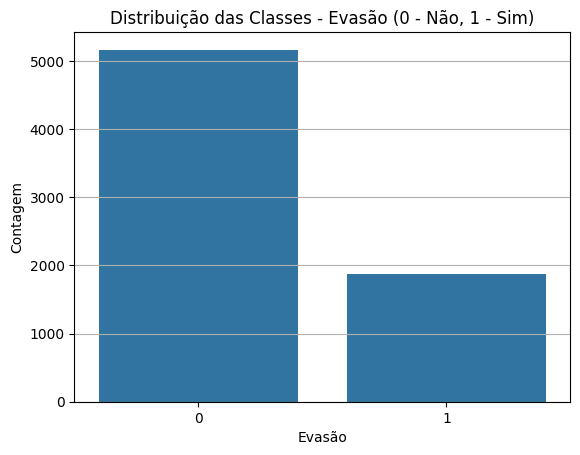

In [14]:
sns.countplot(x='Evasao', data=df_telecomx)
plt.title('Distribuição das Classes - Evasão (0 - Não, 1 - Sim)')
plt.xlabel('Evasão')
plt.ylabel('Contagem')
plt.grid(axis='y')
plt.show()

**Considerações**

- Este cenário revela um moderado desbalanceamento entre as classes. Embora a classe majoritária represente a maior parte dos dados (clientes que não evadiram), ainda há uma quantidade razoável de casos de churn, o que permite treinar modelos preditivos.

- No entanto:

  - Modelos que não lidam bem com desbalanceamento, como Regressão Logística e KNN, podem ser tendenciosos para a classe majoritária, prejudicando o recall da classe minoritária (Churn).

  - Métricas como acurácia podem ser enganosas neste contexto, por isso será essencial avaliar também o Recall, Precisão e F1-score para a classe de churn.

## 4) Encoding das Variáveis Categóricas

### 4.1) Aplicação do One-Hot Encoding com `pd.get_dummies()` :

In [15]:
df_tratado = df_telecomx.copy()

df_encoded = pd.get_dummies(df_tratado, drop_first=True)

In [16]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 25 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Evasao                                              7032 non-null   int64  
 1   Cidadao_Senior                                      7032 non-null   int64  
 2   Parceiro                                            7032 non-null   int64  
 3   Dependentes                                         7032 non-null   int64  
 4   Tempo_Contrato                                      7032 non-null   int64  
 5   Total_Diario                                        7032 non-null   float64
 6   Total_Mensal                                        7032 non-null   float64
 7   Total_Gasto                                         7032 non-null   float64
 8   Genero_Mulher                                       7032 non-null   bool   
 9

In [17]:
df_encoded.head()

,Evasao,Cidadao_Senior,Parceiro,Dependentes,Tempo_Contrato,Total_Diario,Total_Mensal,Total_Gasto,Genero_Mulher,Servico_Telefone_Yes,...,Protecao_Dispositivo_Sim,Suporte_Tecnico_Sim,Streaming_TV_Sim,Streaming_Filmes_Sim,Tipo_Contrato_Bienal,Tipo_Contrato_Mensal,Fatura_Online_Yes,Metodo_Pagamento_Cheque,Metodo_Pagamento_Cheque eletrônico,Metodo_Pagamento_Transferência bancária automático
0,0,0,1,1,9,2.19,65.6,593.30,True,True,...,False,True,True,False,False,False,True,True,False,False
1,0,0,0,0,9,2.00,59.9,542.40,False,True,...,False,False,False,True,False,True,False,True,False,False
2,1,0,0,0,4,2.46,73.9,280.85,False,True,...,True,False,False,False,False,True,True,False,True,False
3,1,1,1,0,13,3.27,98.0,1237.85,False,True,...,True,False,True,True,False,True,True,False,True,False
4,1,1,1,0,3,2.80,83.9,267.40,True,True,...,False,True,True,False,False,True,True,True,False,False


### 4.2) Ajuste de Variáveis Booleanas:

**Considerações**

- Os valores booleanos serão trocados para binário, seguindo a lógica de:

  - True = 1
  - False = 0

In [18]:
bool_cols = df_encoded.select_dtypes(include='bool').columns

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.head()

,Evasao,Cidadao_Senior,Parceiro,Dependentes,Tempo_Contrato,Total_Diario,Total_Mensal,Total_Gasto,Genero_Mulher,Servico_Telefone_Yes,...,Protecao_Dispositivo_Sim,Suporte_Tecnico_Sim,Streaming_TV_Sim,Streaming_Filmes_Sim,Tipo_Contrato_Bienal,Tipo_Contrato_Mensal,Fatura_Online_Yes,Metodo_Pagamento_Cheque,Metodo_Pagamento_Cheque eletrônico,Metodo_Pagamento_Transferência bancária automático
0,0,0,1,1,9,2.19,65.6,593.30,1,1,...,0,1,1,0,0,0,1,1,0,0
1,0,0,0,0,9,2.00,59.9,542.40,0,1,...,0,0,0,1,0,1,0,1,0,0
2,1,0,0,0,4,2.46,73.9,280.85,0,1,...,1,0,0,0,0,1,1,0,1,0
3,1,1,1,0,13,3.27,98.0,1237.85,0,1,...,1,0,1,1,0,1,1,0,1,0
4,1,1,1,0,3,2.80,83.9,267.40,1,1,...,0,1,1,0,0,1,1,1,0,0


In [19]:
# Criar o arquivo .csv para o dataframe 'df_encoded':
df_encoded.to_csv('df_encoded.csv', index=False)

## 5) Análise de Correlação

### 5.1) Visualização com Heatmap:

In [20]:
corr_matrix = df_encoded.corr()
corr_matrix

,Evasao,Cidadao_Senior,Parceiro,Dependentes,Tempo_Contrato,Total_Diario,Total_Mensal,Total_Gasto,Genero_Mulher,Servico_Telefone_Yes,...,Protecao_Dispositivo_Sim,Suporte_Tecnico_Sim,Streaming_TV_Sim,Streaming_Filmes_Sim,Tipo_Contrato_Bienal,Tipo_Contrato_Mensal,Fatura_Online_Yes,Metodo_Pagamento_Cheque,Metodo_Pagamento_Cheque eletrônico,Metodo_Pagamento_Transferência bancária automático
Evasao,1.000000,0.150541,-0.149982,-0.163128,-0.354049,0.192914,0.192858,-0.199484,0.008545,0.011691,...,-0.066193,-0.164716,0.063254,0.060860,-0.301552,0.404565,0.191454,-0.090773,0.301455,-0.118136
Cidadao_Senior,0.150541,1.000000,0.016957,-0.210550,0.015683,0.219848,0.219874,0.102411,0.001819,0.008392,...,0.059514,-0.060577,0.105445,0.119842,-0.116205,0.137752,0.156258,-0.152987,0.171322,-0.016235
Parceiro,-0.149982,0.016957,1.000000,0.452269,0.381912,0.097884,0.097825,0.319072,0.001379,0.018397,...,0.153556,0.120206,0.124483,0.118108,0.247334,-0.280202,-0.013957,-0.096948,-0.083207,0.111406
Dependentes,-0.163128,-0.210550,0.452269,1.000000,0.163386,-0.112395,-0.112343,0.064653,-0.010349,-0.001078,...,0.013900,0.063053,-0.016499,-0.038375,0.201699,-0.229715,-0.110131,0.056448,-0.149274,0.052369
Tempo_Contrato,-0.354049,0.015683,0.381912,0.163386,1.000000,0.246874,0.246862,0.825880,-0.005285,0.007877,...,0.361520,0.325288,0.280264,0.285402,0.563801,-0.649346,0.004823,-0.232181,-0.210197,0.243822
Total_Diario,0.192914,0.219848,0.097884,-0.112395,0.246874,1.000000,0.999996,0.651080,0.013829,0.247995,...,0.482563,0.338300,0.629668,0.627206,-0.073288,0.059006,0.351917,-0.376571,0.271144,0.042385
Total_Mensal,0.192858,0.219874,0.097825,-0.112343,0.246862,0.999996,1.000000,0.651065,0.013779,0.248033,...,0.482607,0.338301,0.629668,0.627235,-0.073256,0.058933,0.351930,-0.376568,0.271117,0.042410
Total_Gasto,-0.199484,0.102411,0.319072,0.064653,0.825880,0.651080,0.651065,1.000000,-0.000048,0.113008,...,0.522881,0.432868,0.515709,0.519867,0.358036,-0.446776,0.157830,-0.294708,-0.060436,0.186119
Genero_Mulher,0.008545,0.001819,0.001379,-0.010349,-0.005285,0.013829,0.013779,-0.000048,1.000000,0.007515,...,0.000807,0.008507,0.007124,0.010105,0.003603,0.003251,0.011902,-0.013199,-0.000844,0.015973
Servico_Telefone_Yes,0.011691,0.008392,0.018397,-0.001078,0.007877,0.247995,0.248033,0.113008,0.007515,1.000000,...,-0.070076,-0.095138,-0.021383,-0.033477,0.004442,-0.001243,0.016696,-0.004463,0.002747,0.008271


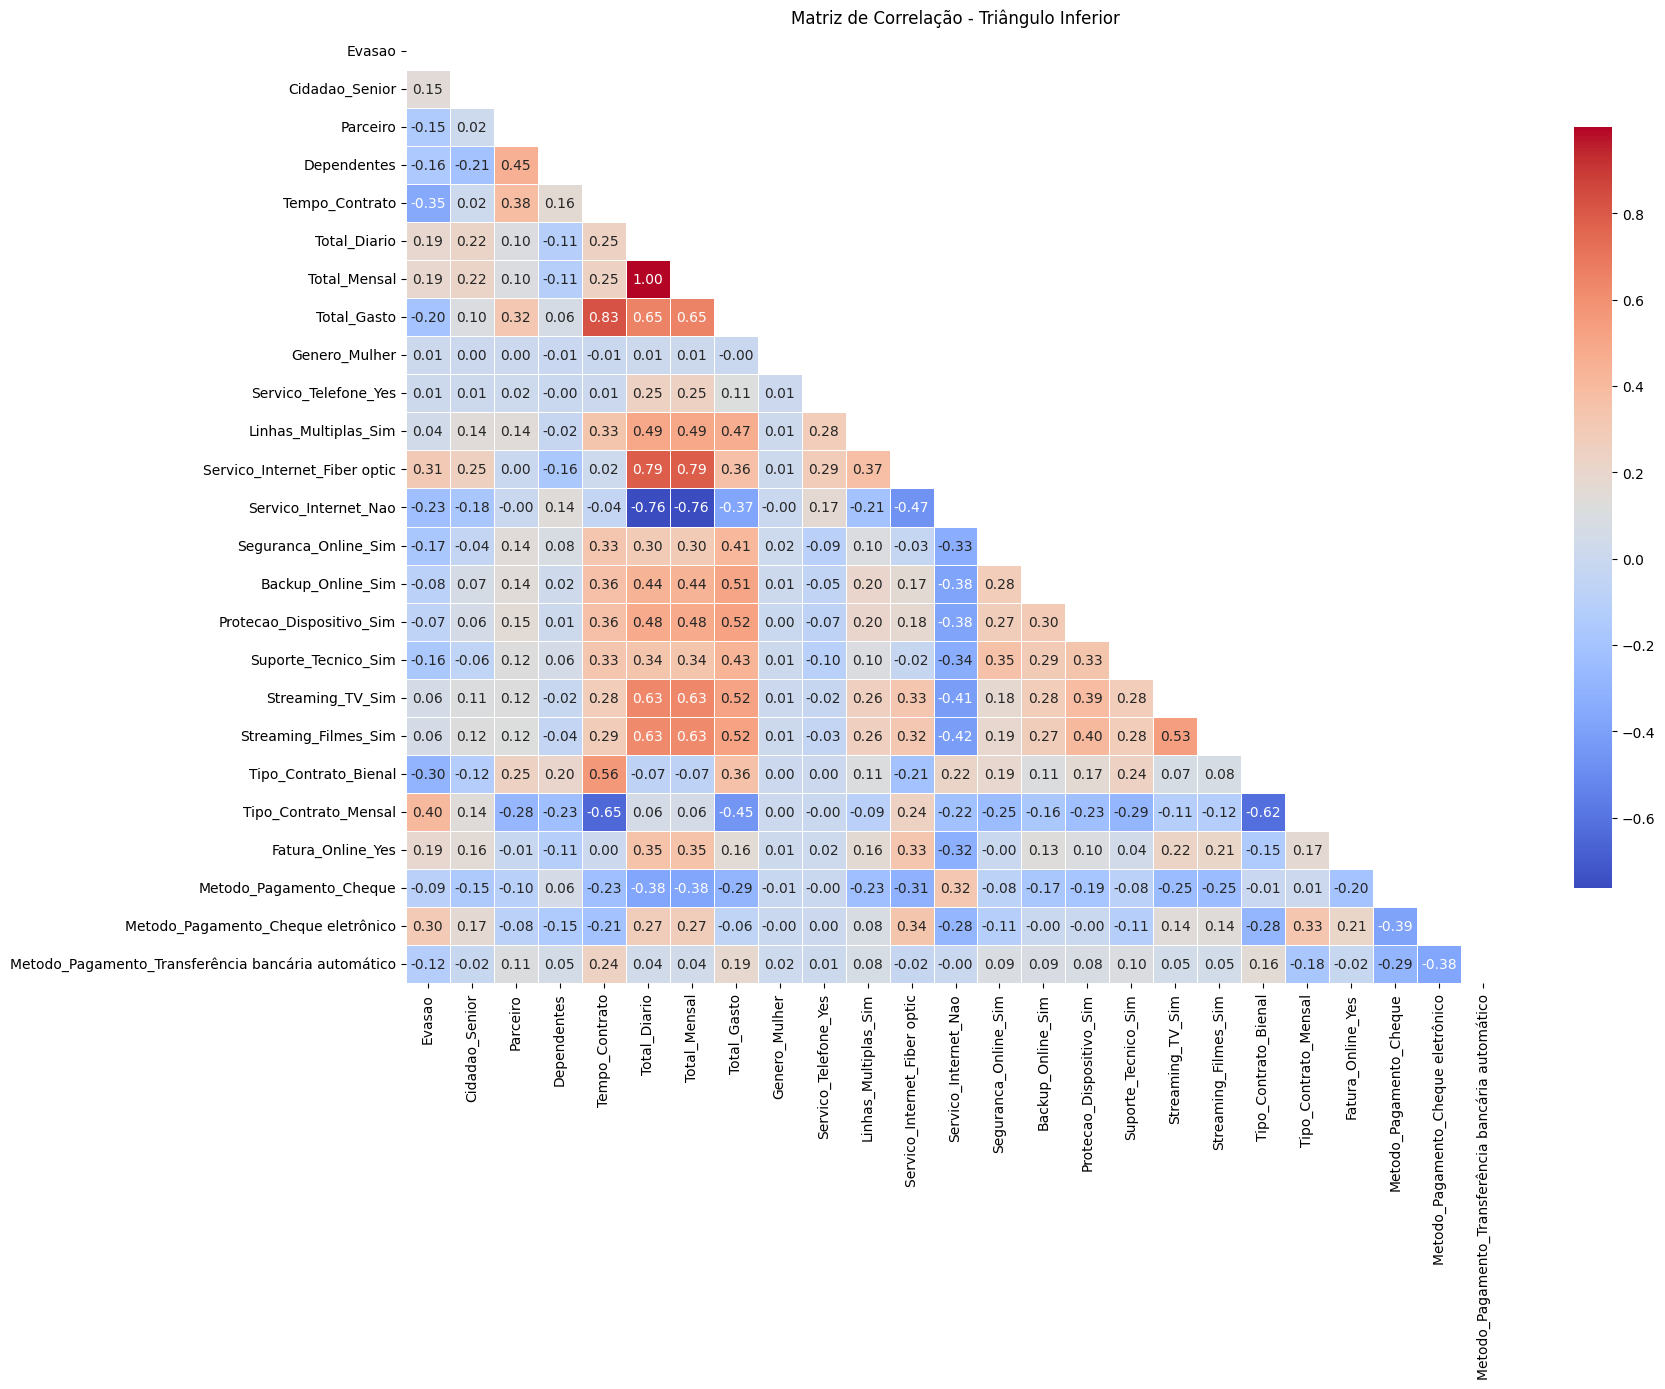

In [21]:
# Gerando máscara para ocultar o triângulo superior:
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap com triângulo inferior:
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    mask=mascara,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Matriz de Correlação - Triângulo Inferior")
plt.tight_layout()
plt.show()

### 5.2) Ranking da Correlação das Variáveis com a Evasão:

In [22]:
# Extraindo as correlações com a variável alvo 'Evasao' e ordenando por magnitude:
corr_churn = corr_matrix['Evasao'].drop('Evasao').sort_values(key=abs, ascending=False)

# Transformando em DataFrame para visualização:
ranking_corr = corr_churn.reset_index()
ranking_corr.columns = ['Variável', 'Correlação com Evasão']
ranking_corr.head(10)

,Variável,Correlação com Evasão
0,Tipo_Contrato_Mensal,0.404565
1,Tempo_Contrato,-0.354049
2,Servico_Internet_Fiber optic,0.307463
3,Tipo_Contrato_Bienal,-0.301552
4,Metodo_Pagamento_Cheque eletrônico,0.301455
5,Servico_Internet_Nao,-0.227578
6,Total_Gasto,-0.199484
7,Total_Diario,0.192914
8,Total_Mensal,0.192858
9,Fatura_Online_Yes,0.191454


## 6) Análise de Multicolinearidade

### 6.1) Cálculo de VIF (Variance Inflation Factor):

| VIF  | Interpretação                              |
|------|--------------------------------------------|
| 1    | Sem multicolinearidade                     |
| 1–5  | Aceitável, baixa multicolinearidade        |
| 5–10 | Moderada, atenção necessária               |
| > 10 | Alta, deve ser tratada                     |


In [23]:
X = df_encoded.drop(columns='Evasao')

X_const = add_constant(X)

vif = pd.DataFrame()
vif['Variável'] = X_const.columns
vif['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

vif.sort_values(by='VIF', ascending=False, inplace=True)
vif

,Variável,VIF
6,Total_Mensal,116030.387810
5,Total_Diario,115434.790268
0,const,639.792777
11,Servico_Internet_Fiber optic,148.529861
12,Servico_Internet_Nao,104.228981
9,Servico_Telefone_Yes,34.896573
18,Streaming_Filmes_Sim,24.158423
17,Streaming_TV_Sim,24.084493
7,Total_Gasto,10.813113
4,Tempo_Contrato,7.584588


### 6.2) Exclusão de Variáveis com VIF Muito Alto:

**Considerações:**

<br>

| Variável                       | VIF        | Diagnóstico                     | Decisão Recomendada                          |
|--------------------------------|------------|----------------------------------|----------------------------------------------|
| Total_Mensal                   | 116030.39  | Multicolinearidade extrema       | Remover                                      |
| Total_Diario                   | 115434.79  | Multicolinearidade extrema       | Remover                                      |
| Servico_Internet_Fiber optic   | 148.53     | Multicolinearidade alta          | Remover                                      |
| Servico_Internet_Nao           | 104.23     | Multicolinearidade alta          | Remover                                      |
| Servico_Telefone_Yes           | 34.90      | Multicolinearidade moderada/alta | Remoção opcional                              |
| Streaming_Filmes_Sim           | 24.16      | Multicolinearidade moderada      | Manter                                       |
| Streaming_TV_Sim               | 24.08      | Multicolinearidade moderada      | Remover                                      |


In [24]:
variaveis_para_remover = [
    'Total_Mensal',
    'Total_Diario',
    'Servico_Internet_Fiber optic',
    'Servico_Internet_Nao',
    'Streaming_TV_Sim',
    'Servico_Telefone_Yes'
]

In [25]:
df_encoded_v2 = df_encoded.copy()
df_encoded_v2.drop(columns=variaveis_para_remover, inplace=True)

In [26]:
df_encoded_v2.to_csv('df_encoded_v2.csv', index=False)

In [27]:
df_encoded_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 19 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Evasao                                              7032 non-null   int64  
 1   Cidadao_Senior                                      7032 non-null   int64  
 2   Parceiro                                            7032 non-null   int64  
 3   Dependentes                                         7032 non-null   int64  
 4   Tempo_Contrato                                      7032 non-null   int64  
 5   Total_Gasto                                         7032 non-null   float64
 6   Genero_Mulher                                       7032 non-null   int64  
 7   Linhas_Multiplas_Sim                                7032 non-null   int64  
 8   Seguranca_Online_Sim                                7032 non-null   int64  
 9

### 6.3) Recalculando o VIF para o Novo Dataframe:

In [28]:
X_v2 = df_encoded_v2.drop(columns='Evasao')

X_const_v2 = add_constant(X_v2)

In [29]:
vif_v2 = pd.DataFrame()
vif_v2['Variável'] = X_const_v2.columns
vif_v2['VIF'] = [variance_inflation_factor(X_const_v2.values, i) for i in range(X_const_v2.shape[1])]

vif_v2.sort_values(by='VIF', ascending=False, inplace=True)

In [30]:
vif_v2

,Variável,VIF
0,const,20.032404
5,Total_Gasto,7.009647
4,Tempo_Contrato,5.892631
14,Tipo_Contrato_Mensal,2.303822
17,Metodo_Pagamento_Cheque eletrônico,1.968850
13,Tipo_Contrato_Bienal,1.854619
16,Metodo_Pagamento_Cheque,1.800012
12,Streaming_Filmes_Sim,1.593207
18,Metodo_Pagamento_Transferência bancária automá...,1.575789
10,Protecao_Dispositivo_Sim,1.477155


## 7) Modelo Não-Linear de Random Forest

### 7.1) Criação:

In [31]:
df_modelagem = df_encoded_v2.copy()

In [32]:
X = df_modelagem.drop(columns='Evasao')
y = df_modelagem['Evasao']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### 7.2) Balanceamento:

In [34]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

### 7.3) Treinamento:

In [35]:
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_resampled, y_resampled)

RandomForestClassifier(random_state=42)

### 7.4) Previsões:

In [36]:
y_pred_rf = modelo_rf.predict(X_test)

y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

### 7.5) Avaliação:

#### Avaliação Geral:

In [37]:
relatorio = classification_report(y_test, y_pred_rf, output_dict=False)
matriz_confusao = confusion_matrix(y_test, y_pred_rf)

print("Modelo de Random Forest")
print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

print("📋 Classification Report:\n")
print(relatorio)

print("\n🧩 Matriz de Confusão:\n")
print(matriz_confusao)

Modelo de Random Forest
Acurácia: 0.7554502369668247
ROC AUC: 0.7878977754609091
📋 Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.83      0.83      1549
           1       0.54      0.56      0.55       561

    accuracy                           0.76      2110
   macro avg       0.69      0.69      0.69      2110
weighted avg       0.76      0.76      0.76      2110


🧩 Matriz de Confusão:

[[1281  268]
 [ 248  313]]


#### Heatmap da Matriz de Confusão:

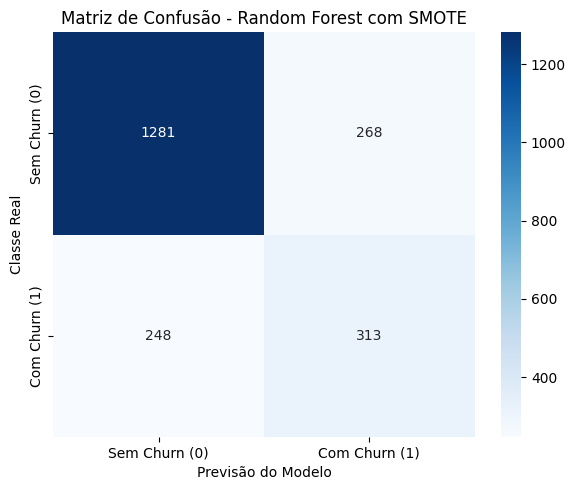

In [38]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_confusao,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Sem Churn (0)', 'Com Churn (1)'],
    yticklabels=['Sem Churn (0)', 'Com Churn (1)']
)

plt.title('Matriz de Confusão - Random Forest com SMOTE')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()

**Interpretação Visual:**

- `Canto superior esquerdo (1281)`: acertos da classe "Sem Churn"

- `Canto inferior direito (313)`: acertos da classe "Com Churn"

- `Canto superior direito (268)`: falsos positivos – previu churn onde não houve

- `Canto inferior esquerdo (248)`: falsos negativos – não previu churn onde houve

#### Curva ROC - Random Forest:

In [39]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

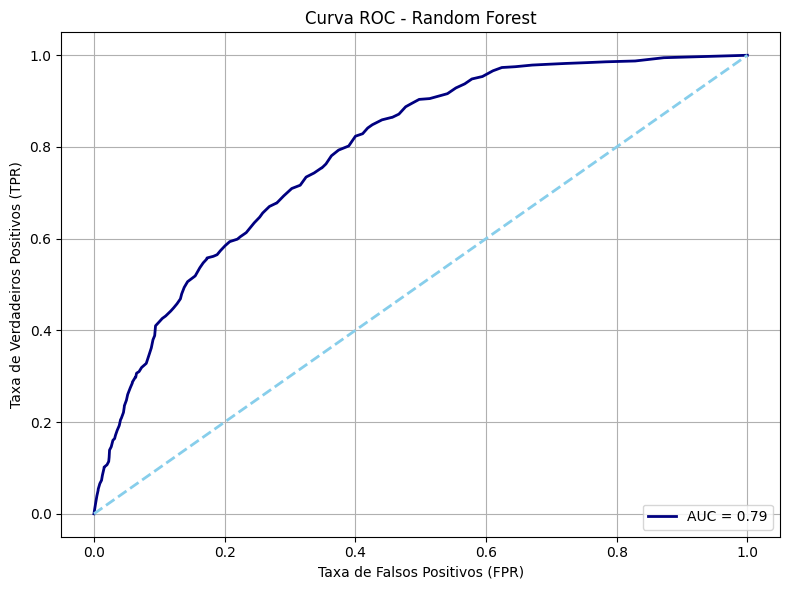

In [40]:
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='navy', lw=2)
plt.plot([0, 1], [0, 1], color='skyblue', lw=2, linestyle='--')

plt.title('Curva ROC - Random Forest')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid()

plt.tight_layout()
plt.show()

**Interpretação Visual**

- A curva representa o desempenho do modelo para diferentes limiares de decisão.

- Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo.

- `AUC (Área Sob a Curva)` foi de aproximadamente 0.79, o que indica bom poder discriminativo.

### 7.6) Análise de Importância das Variáveis:

In [41]:
importancias = modelo_rf.feature_importances_
nomes_variaveis = X.columns

In [42]:
df_importancias_rf = pd.DataFrame({
    'Variável': nomes_variaveis,
    'Importância': importancias
}).sort_values(by='Importância', ascending=False)

df_importancias_rf

,Variável,Importância
4,Total_Gasto,0.249820
3,Tempo_Contrato,0.183912
13,Tipo_Contrato_Mensal,0.080093
12,Tipo_Contrato_Bienal,0.069080
2,Dependentes,0.043893
7,Seguranca_Online_Sim,0.042839
15,Metodo_Pagamento_Cheque,0.041716
10,Suporte_Tecnico_Sim,0.037443
1,Parceiro,0.035980
17,Metodo_Pagamento_Transferência bancária automá...,0.034446


/tmp/ipython-input-3923632767.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


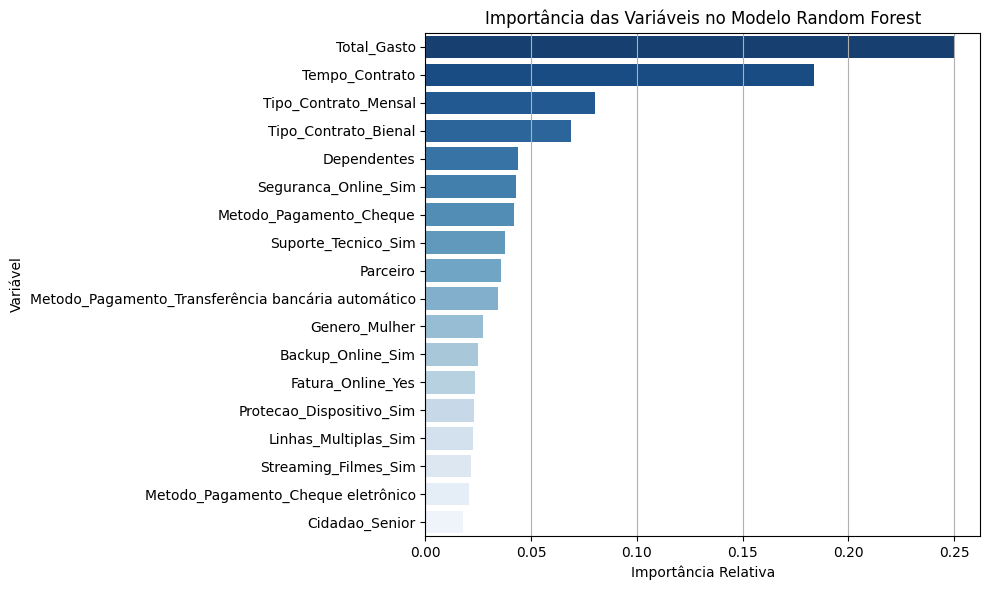

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importancias_rf,
    x='Importância',
    y='Variável',
    palette='Blues_r'
)

plt.title(f'Importância das Variáveis no Modelo Random Forest')
plt.xlabel('Importância Relativa')
plt.ylabel('Variável')
plt.grid(axis='x')

plt.tight_layout()
plt.show()


**Interpretação Visual**

- As variáveis no topo são as que mais influenciam na previsão de churn.

- Variáveis com importância próxima de zero podem ser consideradas irrelevantes neste modelo.

- Essa análise é essencial para gerar insights estratégicos, como por exemplo: `"Clientes com pouco tempo de casa e contrato mensal têm maior chance de evasão."`

## 8) Modelo Não-Linear de XGBoost

### 8.1) Criação e Treinamento:

In [44]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

In [45]:
modelo_xgb = XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=ratio,
    random_state=42
)

In [46]:
modelo_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### 8.2) Previsões:

In [47]:
y_pred_xgb = modelo_xgb.predict(X_test)

y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

### 8.3) Avaliação:

#### Avaliação Geral:

In [48]:
relatorio_xgb = classification_report(y_test, y_pred_xgb, output_dict=False)
matriz_confusao_xgb = confusion_matrix(y_test, y_pred_xgb)

In [49]:
print("Modelo de XGBoost")

print("Acurácia:", accuracy_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\n📋 Classification Report - XGBoost:\n")
print(relatorio_xgb)

print("\n🧩 Matriz de Confusão - XGBoost:\n")
print(matriz_confusao_xgb)

Modelo de XGBoost
Acurácia: 0.7454976303317535
ROC AUC: 0.8129049964959281

📋 Classification Report - XGBoost:

              precision    recall  f1-score   support

           0       0.86      0.78      0.82      1549
           1       0.52      0.66      0.58       561

    accuracy                           0.75      2110
   macro avg       0.69      0.72      0.70      2110
weighted avg       0.77      0.75      0.75      2110


🧩 Matriz de Confusão - XGBoost:

[[1204  345]
 [ 192  369]]


#### Heatmap da Matriz de Confusão:

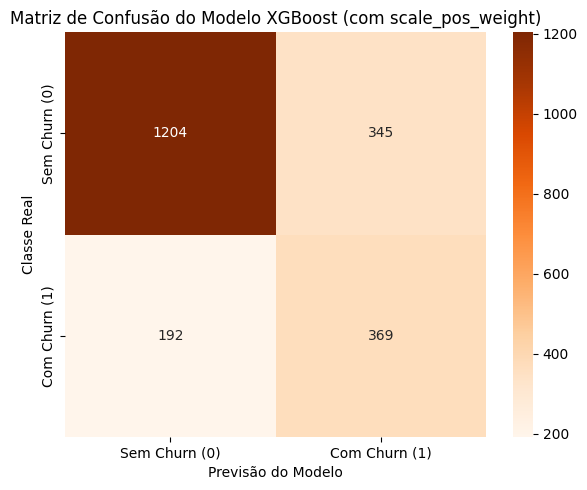

In [50]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    matriz_confusao_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Sem Churn (0)', 'Com Churn (1)'],
    yticklabels=['Sem Churn (0)', 'Com Churn (1)']
)

plt.title('Matriz de Confusão do Modelo XGBoost (com scale_pos_weight)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Classe Real')

plt.tight_layout()
plt.show()

**Interpretação Visual**

- `Canto superior esquerdo (1204)`: acertos da classe "Sem Churn"

- `Canto inferior direito (369)`: acertos da classe "Com Churn"

- `Canto superior direito (345)`: falsos positivos – previu churn onde não houve

- `Canto inferior esquerdo (192)`: falsos negativos – não previu churn onde houve

#### Curva ROC - XGBoost:

In [51]:
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

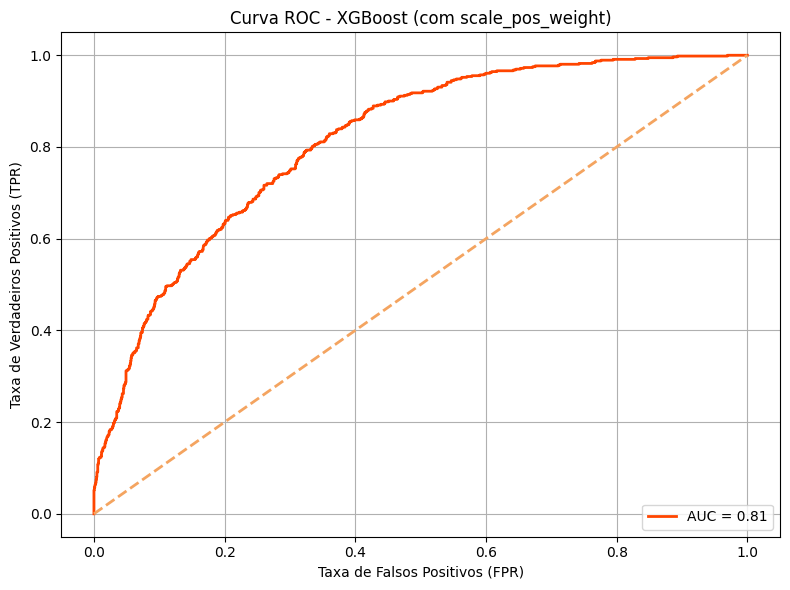

In [52]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'AUC = {roc_auc_xgb:.2f}', color='orangered', lw=2)
plt.plot([0, 1], [0, 1], color='sandybrown', lw=2, linestyle='--')

plt.title('Curva ROC - XGBoost (com scale_pos_weight)')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid()

plt.tight_layout()
plt.show()

**Interpretação Visual**

- O modelo XGBoost tem 81% de chance de distinguir corretamente um cliente que vai evadir de um que vai permanecer, ao comparar um par aleatório.

- A curva sobe rápido no início (entre FPR 0 e 0.2), o que significa que mesmo com baixa taxa de erro, já conseguimos capturar muitos churns verdadeiros.

- Isso é excelente para estratégias preventivas, pois você consegue agir cedo com boa precisão.

### 8.4) Análise de Importância das Variáveis:

In [53]:
importancias_xgb = modelo_xgb.feature_importances_
nomes_variaveis_xgb = X.columns

In [54]:
df_importancias_xgb = pd.DataFrame({
    'Variável': nomes_variaveis_xgb,
    'Importância': importancias_xgb
}).sort_values(by='Importância', ascending=False)

In [55]:
df_importancias_xgb

,Variável,Importância
13,Tipo_Contrato_Mensal,0.574675
12,Tipo_Contrato_Bienal,0.051265
11,Streaming_Filmes_Sim,0.044203
16,Metodo_Pagamento_Cheque eletrônico,0.040055
14,Fatura_Online_Yes,0.026147
6,Linhas_Multiplas_Sim,0.025177
3,Tempo_Contrato,0.024897
0,Cidadao_Senior,0.023964
7,Seguranca_Online_Sim,0.023221
10,Suporte_Tecnico_Sim,0.021876


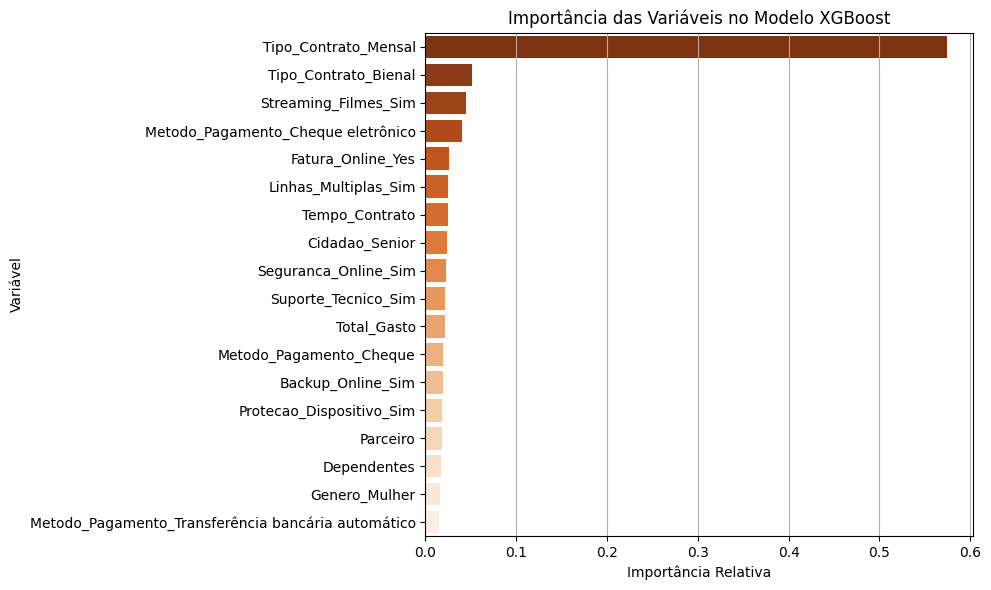

In [56]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importancias_xgb,
    x='Importância',
    y='Variável',
    hue='Variável',
    palette='Oranges_r',
    legend=False
)

plt.title(f'Importância das Variáveis no Modelo XGBoost')
plt.xlabel('Importância Relativa')
plt.ylabel('Variável')
plt.grid(axis='x')

plt.tight_layout()
plt.show()

**Interpretação Visual**

- O tipo de contrato é o fator mais determinante segundo o XGBoost.

- Outros comportamentos como uso de streaming, método de pagamento e faturamento digital também impactam fortemente.

- Essa análise pode direcionar ações de retenção personalizadas, por exemplo: `“Clientes com contrato mensal e débito eletrônico que não usam streaming devem ser prioridade nas campanhas preventivas.”`.

## 9) Modelo Linear de Regressão Logística

### 9.1) Criação:

In [57]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [58]:
df_rlog = df_encoded_v2.copy()

In [59]:
df_rlog.head()

,Evasao,Cidadao_Senior,Parceiro,Dependentes,Tempo_Contrato,Total_Gasto,Genero_Mulher,Linhas_Multiplas_Sim,Seguranca_Online_Sim,Backup_Online_Sim,Protecao_Dispositivo_Sim,Suporte_Tecnico_Sim,Streaming_Filmes_Sim,Tipo_Contrato_Bienal,Tipo_Contrato_Mensal,Fatura_Online_Yes,Metodo_Pagamento_Cheque,Metodo_Pagamento_Cheque eletrônico,Metodo_Pagamento_Transferência bancária automático
0,0,0,1,1,9,593.30,1,0,0,1,0,1,0,0,0,1,1,0,0
1,0,0,0,0,9,542.40,0,1,0,0,0,0,1,0,1,0,1,0,0
2,1,0,0,0,4,280.85,0,0,0,0,1,0,0,0,1,1,0,1,0
3,1,1,1,0,13,1237.85,0,0,0,1,1,0,1,0,1,1,0,1,0
4,1,1,1,0,3,267.40,1,0,0,0,0,1,0,0,1,1,1,0,0


In [60]:
target_col = 'Evasao'

X = df_rlog.drop(columns=[target_col])
y = df_rlog[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

print('Distribuição treino:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Distribuição teste :', y_test.value_counts(normalize=True).round(3).to_dict())

Distribuição treino: {0: 0.734, 1: 0.266}
Distribuição teste : {0: 0.734, 1: 0.266}


### 9.2) Treinamento com Pipeline (StandardScaler + LogisticRegression):

In [61]:
scaler = StandardScaler(with_mean=False) if sparse.issparse(X_train) else StandardScaler()

In [62]:
pipe_lr_bal = Pipeline(steps=[
    ('scaler', scaler),
    ('lr', LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='liblinear',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

In [63]:
modelo_rlog = pipe_lr_bal.fit(X_train, y_train)

### 9.3) Previsões:

In [64]:
y_pred_rlog = modelo_rlog.predict(X_test)
y_prob_rlog = modelo_rlog.predict_proba(X_test)[:, 1]

In [65]:
y_scores_rlog = modelo_rlog.decision_function(X_test)
y_min_rlog, y_max_rlog = y_scores_rlog.min(), y_scores_rlog.max()
y_proba = (y_scores_rlog - y_min_rlog) / (y_max_rlog - y_min_rlog + 1e-9)

### 9.4) Avaliação:

#### Avaliação Geral:

In [66]:
acc = accuracy_score(y_test, y_pred_rlog)
prec = precision_score(y_test, y_pred_rlog, zero_division=0)
rec = recall_score(y_test, y_pred_rlog, zero_division=0)
f1 = f1_score(y_test, y_pred_rlog, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

In [67]:
print('Modelo de Regressão Logística')

print(f'\nAccuracy : {acc:0.4f}')
print(f'Precision: {prec:0.4f}')
print(f'Recall   : {rec:0.4f}')
print(f'F1-Score : {f1:0.4f}')
print(f'ROC AUC  : {auc:0.4f}')

print('\nMatriz de Confusão:')
print(confusion_matrix(y_test, y_pred_rlog))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rlog, digits=4))

Modelo de Regressão Logística

Accuracy : 0.7313
Precision: 0.4968
Recall   : 0.8271
F1-Score : 0.6207
ROC AUC  : 0.8346

Matriz de Confusão:
[[1079  470]
 [  97  464]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9175    0.6966    0.7919      1549
           1     0.4968    0.8271    0.6207       561

    accuracy                         0.7313      2110
   macro avg     0.7072    0.7618    0.7063      2110
weighted avg     0.8057    0.7313    0.7464      2110



#### Heatmap da Matriz de Confusão:

In [68]:
matriz_confusao_rlog = confusion_matrix(y_test, modelo_rlog.predict(X_test))

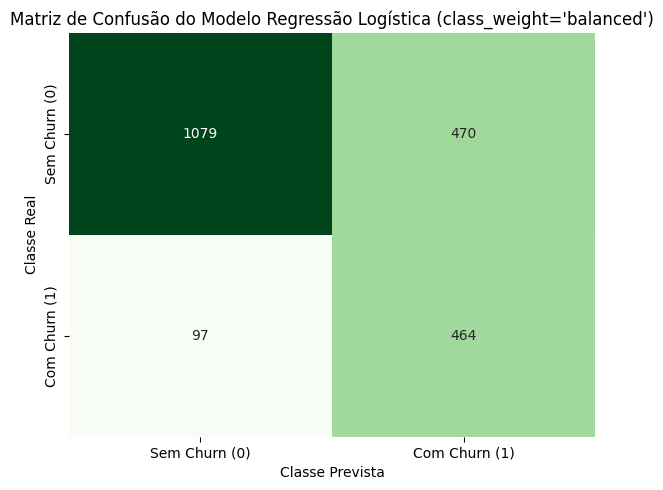

In [69]:
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_confusao_rlog,
            annot=True,
            fmt="d",
            cmap="Greens",
            cbar=False,
            xticklabels=['Sem Churn (0)', 'Com Churn (1)'],
            yticklabels=['Sem Churn (0)', 'Com Churn (1)'])

plt.title("Matriz de Confusão do Modelo Regressão Logística (class_weight='balanced')", fontsize=12)
plt.ylabel("Classe Real")
plt.xlabel("Classe Prevista")

plt.tight_layout()
plt.show()

**Interpretação Visual**

- `Canto superior esquerdo (1079)`: acertos da classe "Sem Churn"

- `Canto inferior direito (464)`: acertos da classe "Com Churn"

- `Canto superior direito (470)`: falsos positivos – previu churn onde não houve

- `Canto inferior esquerdo (97)`: falsos negativos – não previu churn onde houve

#### Curva ROC - Regressão Logística:

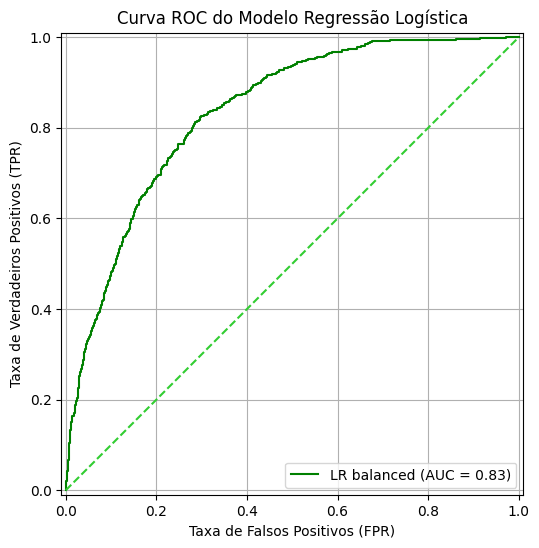

In [70]:
fig, ax = plt.subplots(figsize=(8,6))

RocCurveDisplay.from_estimator(
    pipe_lr_bal,
    X_test,
    y_test,
    name='LR balanced',
    color='green',
    ax=ax
)

ax.plot([0, 1], [0, 1], linestyle='--', color='limegreen')

ax.set_title('Curva ROC do Modelo Regressão Logística')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax.grid(True)

plt.show()


**Interpretação Visual**

- `AUC = 0,83`: O modelo tem boa capacidade discriminatória, conseguindo diferenciar clientes que churnam dos que não churnam com alto grau de confiança.

- Comportamento da curva:

  - A curva está bem acima da diagonal aleatória (linha tracejada), indicando que o modelo é muito melhor que um classificador aleatório.

  - Quanto mais próximo do canto superior esquerdo, melhor — e neste caso, a curva está relativamente próxima, o que confirma boa sensibilidade e especificidade combinadas.

- Implicação estratégica:

  - Esse desempenho permite usar o modelo como ferramenta de triagem para priorizar clientes com maior risco, ajustando o limiar de decisão (threshold) de acordo com o custo de ações de retenção vs. perda de clientes.

#### Curva Precisão-Recall da Regressão Logística:

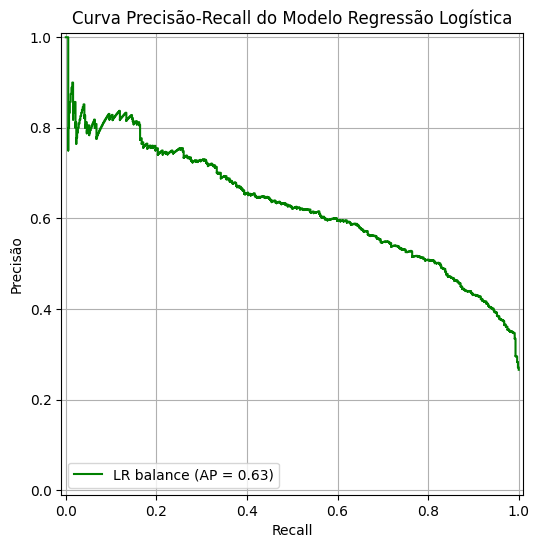

In [71]:
fig, ax = plt.subplots(figsize=(8,6))

PrecisionRecallDisplay.from_estimator(pipe_lr_bal, X_test, y_test, name='LR balance', color='green', ax=ax)

ax.set_title('Curva Precisão-Recall do Modelo Regressão Logística')
ax.set_xlabel('Recall')
ax.set_ylabel('Precisão')
ax.grid(True)

plt.show()

**Interpretação Visual**

- `AP (Average Precision) = 0,63`: Resultado satisfatório considerando que problemas de churn são tipicamente desbalanceados.


- Comportamento da curva:

  - A precisão é alta para valores de recall mais baixos (início da curva), o que significa que quando o modelo é muito conservador nas previsões positivas, ele acerta bastante.

  - Conforme aumentamos o recall (capturando mais clientes em risco), a precisão cai, indicando aumento de falsos positivos.

- Implicação estratégica:

  - Para campanhas de retenção focadas (baixo recall, alta precisão): agir apenas sobre os clientes com maior probabilidade de churn, otimizando custo.

  - Para campanhas de retenção amplas (alto recall, menor precisão): capturar praticamente todos os churns potenciais, aceitando mais ações desnecessárias, mas reduzindo risco de perda.

### 9.5) Ajuste de Limiar (`threshold tuning`) focado no Objetivo de Negócio:

In [72]:
modelo_ref = pipe_lr_bal
proba = modelo_ref.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, proba)

In [73]:
# Regra de negócio: escolher o menor threshold que mantém Precisão >= 0.50:

meta_precisao = 0.50
candidatos = [(t, p, r) for t, p, r in zip(thresholds, precisions[:-1], recalls[:-1]) if p >= meta_precisao]

In [74]:
if candidatos:
    # Ordena por maior recall (dado que atende precisão mínima):
    t_star, p_star, r_star = sorted(candidatos, key=lambda x: x[2], reverse=True)[0]
    print(f'Limiar Escolhido: {t_star:0.3f} | Precisão = {p_star:0.3f} | Recall = {r_star:0.3f}')

    y_pred_t = (proba >= t_star).astype(int)
    print('\nDesempenho com Limiar Ajustado:')
    print('Precision:', precision_score(y_test, y_pred_t))
    print('Recall   :', recall_score(y_test, y_pred_t))
    print('F1       :', f1_score(y_test, y_pred_t))
    print('\nMatriz de Confusão:\n', confusion_matrix(y_test, y_pred_t))
else:
    print('Nenhum threshold atingiu a precisão mínima desejada. Considere outra meta ou SMOTE.')

Limiar Escolhido: 0.503 | Precisão = 0.500 | Recall = 0.827

Desempenho com Limiar Ajustado:
Precision: 0.5
Recall   : 0.8270944741532977
F1       : 0.623237071860309

Matriz de Confusão:
 [[1085  464]
 [  97  464]]


**Implicação Estratégica**

- `Antes do ajuste:` O modelo tinha recall alto, mas precisão moderada, com bastante custo em ações de retenção desnecessárias.

- `Depois do ajuste:` Mantivemos recall alto (82,7%) e fixamos a precisão mínima em 50%, equilibrando melhor custo de retenção e redução de churn.

- `Uso prático:`

  - Adequado para campanhas de retenção amplas, mas com um controle mínimo de desperdício de recursos.

  - A empresa consegue agir sobre quase 80% dos churns reais, aceitando gastar recursos em metade dos casos previstos.

### 9.6) Validação Cruzada (Garantia de Estabilidade):

In [75]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores = cross_validate(
    pipe_lr_bal, X, y,
    scoring=['accuracy','precision','recall','f1','roc_auc'],
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

df_scores_cv = pd.DataFrame(scores).agg(['mean','std']).round(4)

In [76]:
df_scores_cv

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
mean,0.0428,0.0276,0.7241,0.4892,0.8277,0.6148,0.8350
std,0.0021,0.0034,0.0148,0.0161,0.0141,0.0125,0.0056


| Métrica     | Média  | Desvio-Padrão | Interpretação |
|------------|--------|---------------|---------------|
| Accuracy   | 0.7241 | 0.0148 | O modelo acerta cerca de **72,41%** das previsões em média. A variação é um pouco maior (±1,48%), mas ainda indica **consistência razoável** entre os folds. |
| Precision  | 0.4892 | 0.0161 | Aproximadamente **48,92%** das previsões de churn são corretas. Ou seja, **cerca de metade dos clientes classificados como churn realmente cancelam**. A variação moderada (±1,61%) indica leve sensibilidade à divisão dos dados. |
| Recall     | 0.8277 | 0.0141 | O modelo identifica **82,77% dos churns reais**, demonstrando **forte capacidade de detectar clientes em risco**. A baixa variação (±1,41%) indica estabilidade entre os folds. |
| F1-Score   | 0.6148 | 0.0125 | Apresenta um **bom equilíbrio entre precisão e recall**, adequado para problemas de churn. A variação reduzida indica **robustez do modelo**. |
| ROC AUC    | 0.8350 | 0.0056 | Indica **boa capacidade discriminatória (83,50%)** para separar clientes churn e não churn. O desvio-padrão muito baixo reforça a **confiabilidade e estabilidade** do modelo. |


### 9.7) Coeficientes e Odds Ratios:

#### Cálculo dos Coeficientes e Odds:

In [77]:
modelo = pipe_lr_bal.named_steps['lr']
scaler = pipe_lr_bal.named_steps['scaler']

In [78]:
feature_names = X_train.columns

In [79]:
coefs = modelo.coef_.ravel()
odds = np.exp(coefs)

In [80]:
importances = (
    pd.DataFrame({
        'feature': feature_names,
        'coef': coefs,
        'odds_ratio': odds,
        'coef_abs': np.abs(coefs)
    })
    .sort_values('coef_abs', ascending=False)
    .drop(columns=['coef_abs'])
)

In [81]:
importances.head(20)

,feature,coef,odds_ratio
3,Tempo_Contrato,-1.666762,0.188858
4,Total_Gasto,1.117490,3.057170
13,Tipo_Contrato_Mensal,0.446557,1.562921
12,Tipo_Contrato_Bienal,-0.330250,0.718744
16,Metodo_Pagamento_Cheque eletrônico,0.271721,1.312221
14,Fatura_Online_Yes,0.249585,1.283493
11,Streaming_Filmes_Sim,0.170520,1.185921
10,Suporte_Tecnico_Sim,-0.152780,0.858319
0,Cidadao_Senior,0.142787,1.153484
6,Linhas_Multiplas_Sim,0.111065,1.117468


#### Visualização Gráfica:

In [82]:
importances_top20 = pd.DataFrame({
    'feature': [
        'Tempo_Contrato',
        'Total_Gasto',
        'Tipo_Contrato_Mensal',
        'Tipo_Contrato_Bienal',
        'Metodo_Pagamento_Cheque eletrônico',
        'Fatura_Online_Yes',
        'Streaming_Filmes_Sim',
        'Suporte_Tecnico_Sim',
        'Cidadao_Senior',
        'Linhas_Multiplas_Sim',
        'Seguranca_Online_Sim',
        'Metodo_Pagamento_Cheque',
        'Dependentes',
        'Parceiro',
        'Protecao_Dispositivo_Sim',
        'Backup_Online_Sim',
        'Genero_Mulher',
        'Metodo_Pagamento_Transferência bancária automática'
    ],
    'coef': [
        -1.666762,
        1.117490,
        0.446557,
        -0.330250,
        0.271721,
        0.249585,
        0.170520,
        -0.152780,
        0.142787,
        0.111065,
        -0.107468,
        -0.097315,
        -0.051098,
        -0.039949,
        0.030841,
        -0.030768,
        0.026628,
        0.012013
    ]
})


In [83]:
importances_top20['coef_abs'] = importances_top20['coef'].abs()
importances_top20 = importances_top20.sort_values('coef_abs', ascending=True)

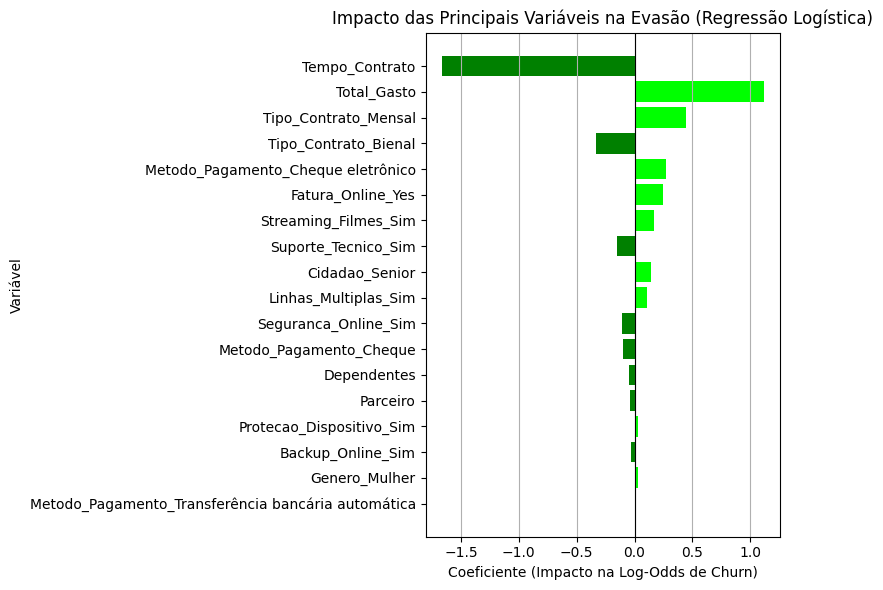

In [84]:
plt.figure(figsize=(8, 6))
plt.barh(importances_top20['feature'], importances_top20['coef'], color=['green' if x < 0 else 'lime' for x in importances_top20['coef']])
plt.axvline(0, color='black', linewidth=0.8)

plt.title("Impacto das Principais Variáveis na Evasão (Regressão Logística)")
plt.xlabel("Coeficiente (Impacto na Log-Odds de Churn)")
plt.ylabel("Variável")
plt.grid(axis='x')

plt.tight_layout()
plt.show()

| Feature | Coef | OR | Interpretação |
|--------|------|----|---------------|
| Tempo_Contrato | -1,6668 | 0,19 | Clientes com maior tempo de contrato têm cerca de **81% menos chance de churn**, sendo um **fortíssimo fator de retenção** e lealdade ao serviço. |
| Total_Gasto | 1,1175 | 3,06 | Clientes com maior gasto total apresentam **aproximadamente 3 vezes mais chance de churn**, possivelmente associado à **sensibilidade a custos acumulados** ou percepção de preço elevado. |
| Tipo_Contrato_Mensal | 0,4466 | 1,56 | Contratos mensais aumentam a chance de churn em **56%**, refletindo **baixo compromisso de longo prazo**. |
| Tipo_Contrato_Bienal | -0,3303 | 0,72 | Contratos bienais reduzem o churn em cerca de **28%**, indicando **maior estabilidade e fidelização**. |
| Metodo_Pagamento_Cheque eletrônico | 0,2717 | 1,31 | Pagamento via cheque eletrônico aumenta a chance de churn em **31%**, podendo indicar **menor engajamento ou perfil menos fiel**. |
| Fatura_Online_Yes | 0,2496 | 1,28 | Clientes com fatura online apresentam **28% mais chance de churn**, possivelmente associados a **perfis mais digitais e menos vinculados ao serviço**. |
| Streaming_Filmes_Sim | 0,1705 | 1,19 | Uso de streaming de filmes aumenta o churn em **19%**, possivelmente relacionado a **maior comparação com serviços concorrentes**. |
| Suporte_Tecnico_Sim | -0,1528 | 0,86 | Ter suporte técnico reduz a chance de churn em aproximadamente **14%**, funcionando como **fator de retenção**. |
| Cidadao_Senior | 0,1428 | 1,15 | Clientes idosos apresentam **15% mais chance de churn**, o que pode refletir **dificuldades com tecnologia ou sensibilidade a preço**. |
| Linhas_Multiplas_Sim | 0,1111 | 1,12 | Ter múltiplas linhas aumenta o churn em **12%**, possivelmente associado a **custos adicionais ou maior complexidade do serviço**. |
| Seguranca_Online_Sim | -0,1075 | 0,90 | Segurança online reduz a chance de churn em cerca de **10%**, indicando **maior percepção de valor agregado**. |
| Metodo_Pagamento_Cheque | -0,0973 | 0,91 | Pagamento via cheque tradicional reduz o churn em **9%**, podendo refletir **clientes mais conservadores e fiéis**. |
| Dependentes | -0,0511 | 0,95 | Clientes com dependentes têm cerca de **5% menos chance de churn**, sugerindo **maior estabilidade e necessidade do serviço**. |
| Parceiro | -0,0399 | 0,96 | Ter parceiro reduz levemente o churn (**~4%**), indicando **maior vínculo familiar com o serviço**. |
| Protecao_Dispositivo_Sim | 0,0308 | 1,03 | Proteção de dispositivo tem **impacto marginal**, com leve aumento de churn (**~3%**), sem relevância prática significativa. |
| Backup_Online_Sim | -0,0308 | 0,97 | Backup online reduz churn em cerca de **3%**, efeito pequeno, mas coerente como **serviço complementar de retenção**. |
| Genero_Mulher | 0,0266 | 1,03 | O gênero feminino apresenta **impacto praticamente neutro**, com aumento de churn de apenas **~3%**, sem relevância operacional. |
| Metodo_Pagamento_Transferência bancária automática | 0,0120 | 1,01 | Forma de pagamento por transferência automática tem **efeito praticamente nulo** no churn. |


#### Implicação Estratégica:

- **Principais Fatores de Retenção**

	- Tempo_Contrato é, de forma disparada, o principal fator de proteção contra churn, reduzindo a chance de evasão em mais de 80%.

	- Contratos bienais apresentam efeito relevante de retenção, reforçando a importância do compromisso de longo prazo.

	- Serviços de valor agregado, como Suporte Técnico e Segurança Online, reduzem consistentemente a probabilidade de churn, indicando maior percepção de valor pelo cliente.

	- Perfis com dependentes e parceiro apresentam menor propensão à evasão, sugerindo maior estabilidade e vínculo com o serviço.

<br>

- **Principais Fatores de Risco**

	- Total_Gasto é o principal fator de risco, com clientes de maior gasto acumulado apresentando cerca de 3 vezes mais chance de churn, possivelmente por sensibilidade ao custo total.

	- Tipo_Contrato_Mensal aumenta significativamente a probabilidade de churn, refletindo baixo nível de fidelização.

	- Método de pagamento via cheque eletrônico e fatura online estão associados a maior rotatividade, possivelmente ligados a clientes mais digitais e menos engajados.

	- Clientes com múltiplas linhas e usuários de streaming de filmes apresentam maior propensão à evasão, possivelmente relacionada a custos adicionais ou comparação com serviços concorrentes.

	- Clientes idosos (Cidadao_Senior) apresentam risco ligeiramente maior de churn, indicando necessidade de abordagens e suporte mais adequados.

<br>

- **Ações Sugeridas**

	- Desenvolver programas de retenção direcionados a clientes com baixo tempo de contrato e alto gasto total, atuando preventivamente nos primeiros meses.

	- Incentivar a migração para contratos bienais, oferecendo descontos ou benefícios exclusivos.

	- Revisar estratégias de preço e pacotes para clientes com alto gasto acumulado, reduzindo a percepção de custo excessivo.

	- Criar campanhas específicas para clientes digitais, especialmente aqueles com fatura online e pagamento via cheque eletrônico, reforçando valor e engajamento.

	- Ampliar e comunicar melhor os benefícios de serviços complementares, como Suporte Técnico, Segurança Online e Backup Online, reforçando seu papel na retenção.


## 10) Modelo Linear de Ridge Classifier

### 10.1) Criação:

In [85]:
RANDOM_STATE = 42

target_col = 'Evasao'

y = df_encoded_v2[target_col].astype(int)
X = df_encoded_v2.drop(columns=[target_col])

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

### 10.2) Pipeline com StandardScaler + RidgeClassifier:

In [87]:
pipe_ridge = Pipeline(steps=[
    ('scaler', scaler),
    ('ridge', RidgeClassifier(
        alpha=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

In [88]:
pipe_ridge.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('ridge',
                 RidgeClassifier(class_weight='balanced', random_state=42))])

In [89]:
modelo_rc = pipe_ridge.fit(X_train, y_train)

### 10.3) Previsão e Avaliação:

#### Previsão:

In [90]:
y_pred_rc = modelo_rc.predict(X_test)
y_pred_rc

array([0, 1, 0, ..., 0, 0, 0])

#### Avaliação Geral:

In [91]:
acc  = accuracy_score(y_test, y_pred_rc)
prec = precision_score(y_test, y_pred_rc, zero_division=0)
rec  = recall_score(y_test, y_pred_rc, zero_division=0)
f1   = f1_score(y_test, y_pred_rc, zero_division=0)

In [92]:
print("Modelo de Ridge Classifier")

print(f"\nAccuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rc))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rc, digits=4))

Modelo de Ridge Classifier

Accuracy : 0.7128
Precision: 0.4775
Recall   : 0.8503
F1-Score : 0.6115

Matriz de Confusão:
[[1027  522]
 [  84  477]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9244    0.6630    0.7722      1549
           1     0.4775    0.8503    0.6115       561

    accuracy                         0.7128      2110
   macro avg     0.7009    0.7566    0.6919      2110
weighted avg     0.8056    0.7128    0.7295      2110



#### Heatmap da Matriz de Confusão:

In [93]:
matriz_confusao = confusion_matrix(y_test, y_pred_rc)

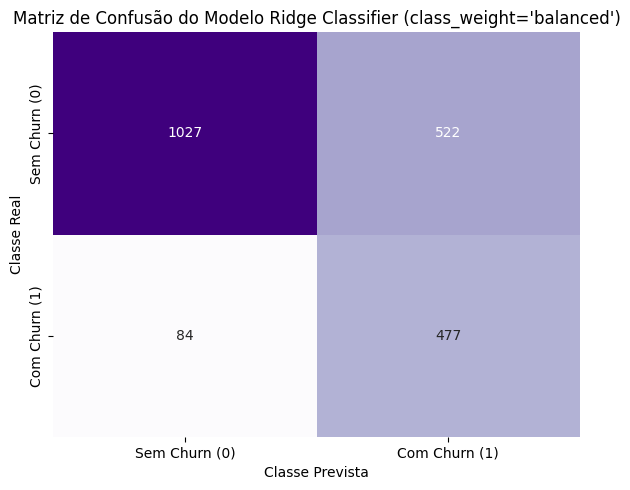

In [94]:
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_confusao,
            annot=True,
            fmt="d",
            cmap="Purples",
            cbar=False,
            xticklabels=['Sem Churn (0)', 'Com Churn (1)'],
            yticklabels=['Sem Churn (0)', 'Com Churn (1)'])

plt.title("Matriz de Confusão do Modelo Ridge Classifier (class_weight='balanced')", fontsize=12)
plt.ylabel("Classe Real")
plt.xlabel("Classe Prevista")

plt.tight_layout()
plt.show()

**Interpretação Visual**

- `Verdadeiros Positivos (TP = 477)`: grande volume de churns corretamente identificados.

- `Falsos Positivos (FP = 522)`: número elevado de clientes abordados sem necessidade.

- `Verdadeiros Negativos (TN = 1027)`: boa capacidade de identificar não churn.

- `Falsos Negativos (FN = 84)`: baixo número de churns não detectados.

#### Curva ROC do Ridge Classifier:

In [95]:
y_scores_rc = modelo_rc.decision_function(X_test)
auc = roc_auc_score(y_test, y_scores_rc)

print(f"ROC AUC: {auc:.4f}")

ROC AUC: 0.8313


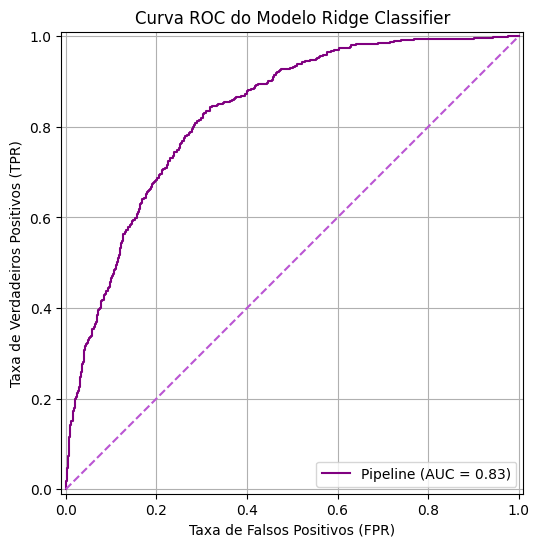

In [96]:
fig, ax = plt.subplots(figsize=(8,6))

RocCurveDisplay.from_estimator(
    modelo_rc,
    X_test,
    y_test,
    ax=ax,
    color='purple')

ax.plot([0, 1], [0, 1], linestyle='--', color='mediumorchid')

ax.set_title('Curva ROC do Modelo Ridge Classifier')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax.grid()

plt.show()

**Interpretação Visual**

- `AUC = 0,83`: Boa capacidade de discriminação entre churn e não churn.

- A curva está bem acima da diagonal aleatória, confirmando que o modelo está aprendendo padrões reais.

- O `Ridge Classifier` está sendo consistente na separação das classes, podendo ser ajustado via threshold para equilibrar precisão e recall.

#### Curva Precisão-Recall do Ridge Classifier:

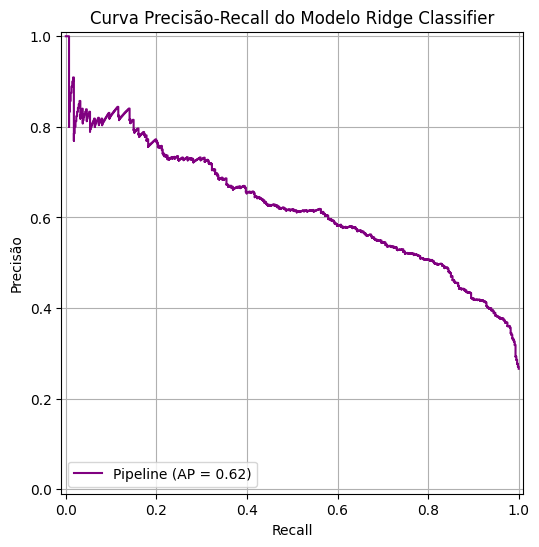

In [97]:
fig, ax = plt.subplots(figsize=(8,6))

PrecisionRecallDisplay.from_estimator(
    pipe_ridge,
    X_test,
    y_test,
    ax=ax,
    color='purple')

ax.set_title('Curva Precisão-Recall do Modelo Ridge Classifier')
ax.set_xlabel('Recall')
ax.set_ylabel('Precisão')
ax.grid()

plt.show()

**Interpretação Visual**

- `AP = 0,62` : Desempenho bom considerando que churn é um problema com desbalanceamento.

- A curva mostra que:

  - Em pontos de baixo recall, a precisão é alta → útil para campanhas de retenção bem focadas.

  - Conforme o recall aumenta, a precisão cai → custo de mais falsos positivos.

  - Podemos escolher pontos estratégicos dessa curva para balancear custo e impacto de retenção

### 10.4) Ajuste de Limiar (Threshold Tuning):

**Considerações**

- Objetivo: manter `precisão >= 0.50` e maximizar recall.

- `decision_function`: retorna a distância da amostra até o hiperplano de decisão, que podemos usar como "confiança" para definir o threshold.

- `precision_recall_curve`: gera os valores de precisão, recall e thresholds para todos os possíveis pontos de corte.

- `Filtro pela meta de precisão`: selecionamos apenas pontos com precisão ≥ 0,50.

- `Escolha final`: pegamos o ponto que dá o maior recall dentro dessa condição.

- `Reavaliação`: calculamos novamente métricas e matriz de confusão para ver o impacto.

In [98]:
scores_rc = modelo_rc.decision_function(X_test)

precisions, recalls, thresholds = precision_recall_curve(y_test, scores_rc)

In [99]:
meta_precisao = 0.50

candidatos = [(t, p, r) for t, p, r in zip(thresholds, precisions[:-1], recalls[:-1]) if p >= meta_precisao]

if candidatos:
    t_star, p_star, r_star = sorted(candidatos, key=lambda x: x[2], reverse=True)[0]
    print(f"Limiar Escolhido: {t_star:.3f} | Precisão = {p_star:.3f} | Recall = {r_star:.3f}")

    y_pred_tuned = (scores_rc >= t_star).astype(int)

    print("\nDesempenho do Modelo Ridge Classifier com Limiar Ajustado:")
    print("Precision:", precision_score(y_test, y_pred_tuned))
    print("Recall   :", recall_score(y_test, y_pred_tuned))
    print("F1       :", f1_score(y_test, y_pred_tuned))
    print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred_tuned))
else:
    print("Nenhum threshold atingiu a precisão mínima desejada. Considere outra meta.")

Limiar Escolhido: 0.062 | Precisão = 0.500 | Recall = 0.815

Desempenho do Modelo Ridge Classifier com Limiar Ajustado:
Precision: 0.5
Recall   : 0.8146167557932263
F1       : 0.6196610169491525

Matriz de Confusão:
 [[1092  457]
 [ 104  457]]


**Impacto Estratégico**

- `Antes do ajuste`:

   - Recall alto, mas precisão abaixo de 50%;
   
   - Gerando mais ações de retenção em clientes que não iriam sair.

- `Depois do ajuste`:

  - Mantemos recall acima de 80% → continuamos prevenindo a maioria das perdas.

  - Precisão fixada em 50% → reduz desperdício de recursos com clientes que ficariam.

  - Pequeno aumento nos falsos negativos (agora 104), mas ganho relevante no custo-benefício.

### 10.5) Validação Cruzada Estratificada (k-fold):

In [100]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [101]:
scores_ridge = cross_validate(
    pipe_ridge,
    X,
    y,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

In [102]:
df_scores_ridge = pd.DataFrame(scores_ridge).agg(['mean', 'std']).round(4)
df_scores_ridge

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
mean,0.0198,0.0234,0.7100,0.4746,0.8422,0.6070,0.8317
std,0.0043,0.0046,0.0099,0.0099,0.0144,0.0079,0.0057


#### Visão Geral das Métricas:

| Métrica    | Média  | Desvio-Padrão | Interpretação |
|------------|--------|---------------|---------------|
| Accuracy   | 0,7100 | ±0,0099 | O modelo acerta cerca de **71,0%** das previsões em média. A variação é um pouco maior entre os folds, mas ainda indica **estabilidade aceitável**. |
| Precisão   | 0,4746 | ±0,0099 | Aproximadamente **47,5%** das previsões de churn são corretas, indicando presença de **falsos positivos relevantes**. A variação moderada sugere leve sensibilidade à divisão dos dados. |
| Recall     | 0,8422 | ±0,0144 | O modelo identifica cerca de **84,2%** dos clientes que realmente churnam, sendo seu **principal ponto forte**. A baixa variação entre folds indica **confiabilidade**. |
| F1-Score   | 0,6070 | ±0,0079 | Apresenta um **bom equilíbrio entre precisão e recall**, com desempenho consistente ao longo dos folds. |
| ROC AUC    | 0,8317 | ±0,0057 | Demonstra **boa capacidade de separação** entre clientes churn e não churn. O desvio-padrão reduzido confirma a **estabilidade do modelo**. |


### 10.6) Coeficientes e Odds Ratios:

#### Cálculo dos Coeficientes e Odds:

In [103]:
modelo_ridge = pipe_ridge.named_steps['ridge']
scaler_ridge = pipe_ridge.named_steps['scaler']

In [104]:
feature_names = X_train.columns

coefs_ridge = modelo_ridge.coef_.ravel()

odds_ridge = np.exp(coefs_ridge)

In [105]:
importances_ridge = (
    pd.DataFrame({
        'feature': feature_names,
        'coef': coefs_ridge,
        'odds_ratio': odds_ridge,
        'coef_abs': np.abs(coefs_ridge)
    })
    .sort_values('coef_abs', ascending=False)
    .drop(columns=['coef_abs'])
)

In [106]:
importances_ridge.head(20)

,feature,coef,odds_ratio
3,Tempo_Contrato,-0.390577,0.676666
13,Tipo_Contrato_Mensal,0.215677,1.240702
4,Total_Gasto,0.193706,1.213739
16,Metodo_Pagamento_Cheque eletrônico,0.113732,1.120452
14,Fatura_Online_Yes,0.086155,1.089976
11,Streaming_Filmes_Sim,0.067713,1.070058
10,Suporte_Tecnico_Sim,-0.057665,0.943967
0,Cidadao_Senior,0.050614,1.051916
6,Linhas_Multiplas_Sim,0.049514,1.050760
7,Seguranca_Online_Sim,-0.045680,0.955347


#### Visualização Gráfica:

In [107]:
importances_top20 = pd.DataFrame({
    'feature': [
        'Tempo_Contrato', 'Tipo_Contrato_Mensal', 'Total_Gasto',
        'Metodo_Pagamento_Cheque_eletronico', 'Fatura_Online_Yes',
        'Streaming_Filmes_Sim', 'Suporte_Tecnico_Sim', 'Cidadao_Senior',
        'Linhas_Multiplas_Sim', 'Seguranca_Online_Sim',
        'Tipo_Contrato_Bienal', 'Metodo_Pagamento_Cheque',
        'Dependentes', 'Parceiro', 'Protecao_Dispositivo_Sim',
        'Backup_Online_Sim', 'Genero_Mulher',
        'Metodo_Pagamento_Transferencia_bancaria_automatica'
    ],
    'coef': [
        -0.390577, 0.215677, 0.193706, 0.113732, 0.086155,
        0.067713, -0.057665, 0.050614, 0.049514, -0.045680,
        -0.038078, -0.037087, -0.019136, -0.014801,
        0.013807, -0.012066, 0.008900, 0.005278
    ]
})


In [108]:
importances_top20['coef_abs'] = importances_top20['coef'].abs()
importances_top20 = importances_top20.sort_values('coef_abs', ascending=True)

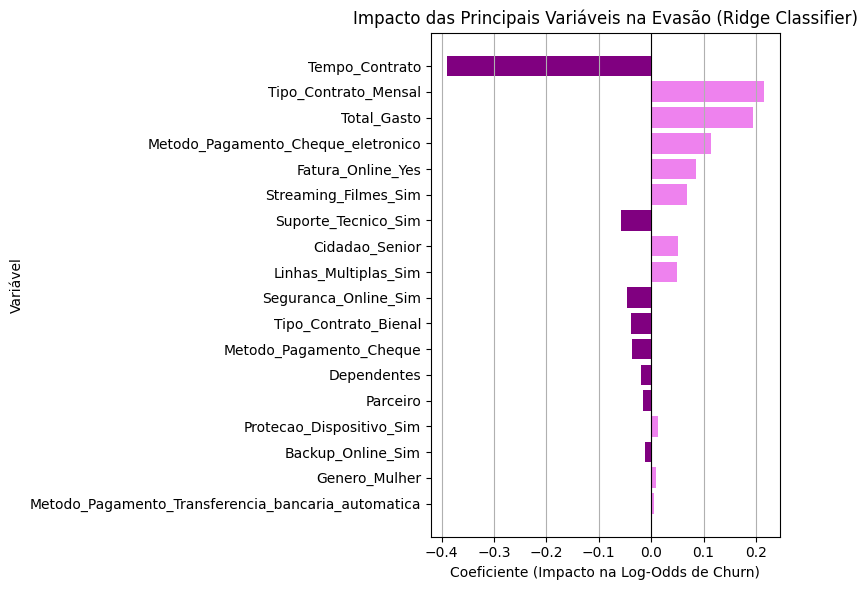

In [109]:
plt.figure(figsize=(8, 6))
plt.barh(
    importances_top20['feature'],
    importances_top20['coef'],
    color=['purple' if x < 0 else 'violet' for x in importances_top20['coef']]
)

plt.axvline(0, color='black', linewidth=0.8)

plt.title("Impacto das Principais Variáveis na Evasão (Ridge Classifier)")
plt.xlabel("Coeficiente (Impacto na Log-Odds de Churn)")
plt.ylabel("Variável")
plt.grid(axis='x')

plt.tight_layout()
plt.show()

| Feature                                      | Coef     | OR       | Interpretação |
|---------------------------------------------|----------|----------|---------------|
| Tempo_Contrato                              | -0,3906  | 0,68     | Clientes com maior tempo de contrato têm cerca de 32% menos chance de churn, sendo o principal fator de retenção. |
| Tipo_Contrato_Mensal                        | 0,2157   | 1,24     | Contratos mensais aumentam o churn em 24%, indicando menor comprometimento de longo prazo. |
| Total_Gasto                                 | 0,1937   | 1,21     | Clientes com maior gasto total têm cerca de 21% mais chance de churn, possivelmente por insatisfação com o custo acumulado. |
| Metodo_Pagamento_Cheque eletrônico          | 0,1137   | 1,12     | Pagamento via cheque eletrônico aumenta o churn em ~12%, podendo refletir menor fidelidade ou engajamento. |
| Fatura_Online_Yes                           | 0,0862   | 1,09     | Fatura online aumenta o churn em ~9%, associada a perfis mais digitais e menos fiéis. |
| Streaming_Filmes_Sim                        | 0,0677   | 1,07     | Usuários de streaming de filmes apresentam 7% mais chance de churn, possivelmente ligados a maior concorrência de serviços. |
| Suporte_Tecnico_Sim                         | -0,0577  | 0,94     | Suporte técnico reduz o churn em cerca de 6%, funcionando como fator de retenção. |
| Cidadao_Senior                              | 0,0506   | 1,05     | Clientes idosos têm aproximadamente 5% mais chance de churn. |
| Linhas_Multiplas_Sim                        | 0,0495   | 1,05     | Ter múltiplas linhas aumenta o churn em ~5%, possivelmente devido a custos adicionais. |
| Seguranca_Online_Sim                        | -0,0457  | 0,96     | Segurança online reduz o churn em cerca de 4–5%, contribuindo para retenção. |
| Tipo_Contrato_Bienal                        | -0,0381  | 0,96     | Contratos bienais reduzem o churn em ~4%, indicando maior estabilidade do cliente. |
| Metodo_Pagamento_Cheque                     | -0,0371  | 0,96     | Pagamento via cheque tradicional reduz levemente o churn (~4%). |
| Dependentes                                 | -0,0191  | 0,98     | Clientes com dependentes apresentam cerca de 2% menos chance de churn, sugerindo maior vínculo. |
| Parceiro                                    | -0,0148  | 0,99     | Ter parceiro(a) reduz o churn de forma marginal, com impacto baixo. |
| Protecao_Dispositivo_Sim                    | 0,0138   | 1,01     | Proteção de dispositivo tem impacto praticamente neutro no churn. |
| Backup_Online_Sim                           | -0,0121  | 0,99     | Backup online reduz o churn em cerca de 1%, com efeito pequeno. |
| Genero_Mulher                               | 0,0089   | 1,01     | Gênero feminino apresenta impacto praticamente neutro no risco de churn. |
| Metodo_Pagamento_Transferência bancária automática | 0,0053 | 1,01 | Transferência bancária automática não altera significativamente a probabilidade de churn. |


#### Implicação Estratégica:

- **Principais fatores de retenção:**
	- Tempo de contrato é o fator mais relevante de retenção, reduzindo significativamente a probabilidade de churn à medida que o vínculo com a empresa aumenta.
	- Contratos de maior duração, especialmente os bienais, apresentam menor taxa de evasão quando comparados aos contratos mensais.
	- Serviços adicionais de valor, como suporte técnico e segurança online, contribuem de forma consistente para a permanência do cliente.
	- Características de vínculo familiar, como ter dependentes ou parceiro, embora com impacto menor, também ajudam levemente na retenção.
<br>

- **Principais fatores de risco:**
	- Contratos mensais representam o principal fator estrutural de risco, aumentando significativamente a chance de churn.
	- Clientes com maior gasto total apresentam maior propensão ao cancelamento, possivelmente por percepção negativa do custo-benefício.
	- Pagamentos via cheque eletrônico e fatura online estão associados a maior churn, indicando perfis mais digitais e potencialmente menos fiéis.
	- Clientes com múltiplas linhas e usuários de streaming de filmes demonstram maior tendência ao cancelamento, possivelmente relacionada a custos adicionais ou maior exposição à concorrência.
	- O perfil de clientes idosos apresenta leve aumento do risco de churn, sugerindo a necessidade de atenção específica a esse grupo.


## 11) Comparação dos Modelos

### 11.1) Função para Cálculo de Métricas:

In [110]:
def calcular_metricas(modelo, X_test, y_test, nome):
    try:
        y_proba = modelo.predict_proba(X_test)[:, 1]
    except AttributeError:
        # Para modelos sem predict_proba (ex.: Ridge), usar decision_function
        y_scores = modelo.decision_function(X_test)
        # Normalizar para [0, 1] antes do cálculo do ROC AUC
        y_min, y_max = y_scores.min(), y_scores.max()
        y_proba = (y_scores - y_min) / (y_max - y_min + 1e-9)

    y_pred = modelo.predict(X_test)

    return {
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }

In [111]:
modelos_comparar = [
    (modelo_rf, X_test, y_test, "Random Forest"),
    (modelo_xgb, X_test, y_test, "XGBoost"),
    (modelo_rlog, X_test, y_test, "Logistic Regression (Balanced)"),
    (modelo_rc, X_test, y_test, "Ridge Classifier (Balanced)")
]

In [112]:
resultados = [calcular_metricas(m, X, y, nome) for m, X, y, nome in modelos_comparar]

In [113]:
df_comparacao = pd.DataFrame(resultados).round(4)
df_comparacao

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Random Forest,0.7555,0.5387,0.5579,0.5482,0.7879
1,XGBoost,0.7455,0.5168,0.6578,0.5788,0.8129
2,Logistic Regression (Balanced),0.7313,0.4968,0.8271,0.6207,0.8346
3,Ridge Classifier (Balanced),0.7128,0.4775,0.8503,0.6115,0.8313


In [114]:
df_comparacao.to_csv("df_comparacao_metricas.csv", index=False)

### 11.2) Comparação Visual - Por Modelo:

In [115]:
metricas = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC"]
labels = df_comparacao["Modelo"].tolist()
x = np.arange(len(labels))
largura = 0.16
offsets = np.linspace(-2, 2, num=len(metricas)) * largura

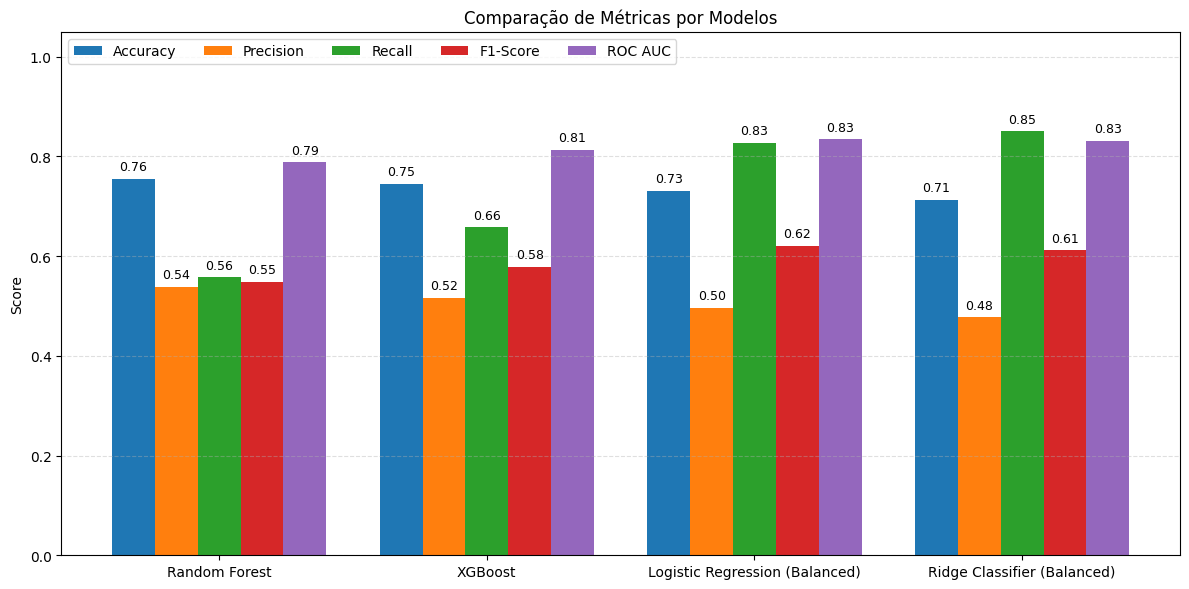

In [116]:
fig, ax = plt.subplots(figsize=(12, 6))
barras = []

for i, m in enumerate(metricas):
    valores = df_comparacao[m].values
    b = ax.bar(x + offsets[i], valores, largura, label=m)
    barras.append(b)
    for rect in b:
        h = rect.get_height()
        ax.annotate(f'{h:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center',
                    va='bottom',
                    fontsize=9)

ax.set_title("Comparação de Métricas por Modelos")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)

ax.legend(loc='upper left', ncols=len(metricas))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [117]:
fig.savefig("grafico_comp_modelos.png", dpi=140, bbox_inches='tight')

### 11.3) Comparação Visual - Por Métricas:

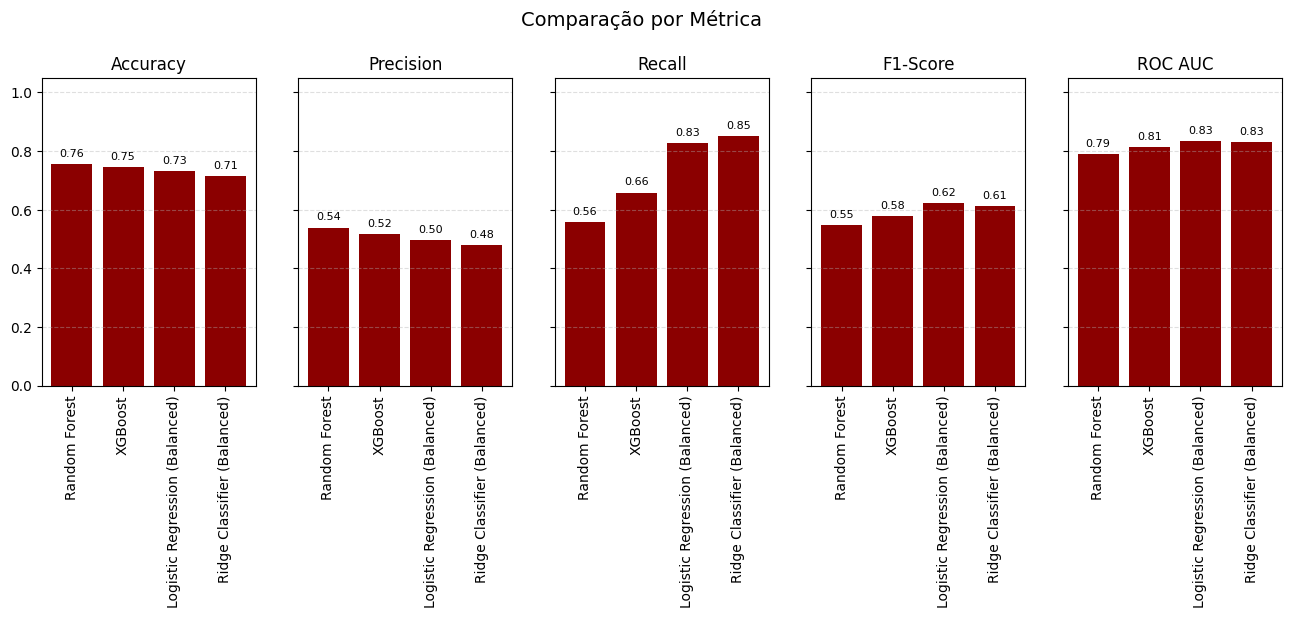

In [118]:
fig2, axes = plt.subplots(nrows=1, ncols=len(metricas), figsize=(16, 4), sharey=True)

for i, m in enumerate(metricas):
    axes[i].bar(labels, df_comparacao[m].values, color='darkred')
    axes[i].set_title(m)
    axes[i].set_ylim(0, 1.05)
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)
    for xi, val in enumerate(df_comparacao[m].values):
        axes[i].annotate(f'{val:.2f}', xy=(xi, val), xytext=(0,4), textcoords='offset points',
                         ha='center', va='bottom', fontsize=8)

fig2.suptitle("Comparação por Métrica", y=1.05, fontsize=14)
plt.show()

In [119]:
fig2.savefig("graf_comp_metricas.png", dpi=140, bbox_inches='tight')

### 11.4) Ranking Automático por Métricas:

In [120]:
ranking = {}

for m in metricas:
    melhor_valor = df_comparacao[m].max()
    melhores = df_comparacao[df_comparacao[m] == melhor_valor]["Modelo"].tolist()
    ranking[m] = {"Melhor Valor": melhor_valor, "Melhor(es) Modelo(s)": melhores}

In [121]:
df_ranking = pd.DataFrame(ranking).T
df_ranking

,Melhor Valor,Melhor(es) Modelo(s)
Accuracy,0.7555,[Random Forest]
Precision,0.5387,[Random Forest]
Recall,0.8503,[Ridge Classifier (Balanced)]
F1-Score,0.6207,[Logistic Regression (Balanced)]
ROC AUC,0.8346,[Logistic Regression (Balanced)]


In [122]:
df_ranking.to_csv('df_ranking.csv')

In [123]:
for m in metricas:
    modelos = ', '.join(ranking[m]["Melhor(es) Modelo(s)"])
    valor = ranking[m]["Melhor Valor"]
    print(f"- {m}: melhor desempenho ({valor:.4f}) obtido por {modelos}.")

- Accuracy: melhor desempenho (0.7555) obtido por Random Forest.
- Precision: melhor desempenho (0.5387) obtido por Random Forest.
- Recall: melhor desempenho (0.8503) obtido por Ridge Classifier (Balanced).
- F1-Score: melhor desempenho (0.6207) obtido por Logistic Regression (Balanced).
- ROC AUC: melhor desempenho (0.8346) obtido por Logistic Regression (Balanced).


### 11.5) Regra de Negócio para Escolha do Modelo Prioritário:

**Considerações**

- Priorizar modelo com maior Recall de Precisão >= 0.50;

- Em caso de empate, considerar o modelo de maior F1;

- Se ninguém atinge a precisão mínima, escolher o modelo com melhor F1.

In [124]:
df_regra = df_comparacao.copy()
df_validos = df_regra[df_regra["Precision"] >= 0.50].copy()
df_validos

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Random Forest,0.7555,0.5387,0.5579,0.5482,0.7879
1,XGBoost,0.7455,0.5168,0.6578,0.5788,0.8129


In [125]:
if not df_validos.empty:
    df_validos = df_validos.sort_values(by=["Recall", "F1-Score"], ascending=False)
    modelo_prioritario = df_validos.iloc[0]["Modelo"]
    criterio = "Recall (com Precision ≥ 0,50), desempate por F1"
else:
    df_fallback = df_regra.sort_values(by=["F1-Score", "Recall"], ascending=False)
    modelo_prioritario = df_fallback.iloc[0]["Modelo"]
    criterio = "F1-Score (fallback; nenhum modelo atingiu Precision ≥ 0,50)"

In [126]:
print(f'Critério Utilizado: {criterio}.')
print(f'Modelo Prioritário: {modelo_prioritario}.')

Critério Utilizado: Recall (com Precision ≥ 0,50), desempate por F1.
Modelo Prioritário: XGBoost.


# Relatório Final – Projeto Telecom X (Parte 2)

## 1. Visão Geral do Projeto

O projeto **Telecom X – Parte 2** tem como objetivo principal **analisar, modelar e prever a evasão de clientes (churn)** em uma empresa de telecomunicações, utilizando técnicas de **Análise Exploratória de Dados, Estatística e Machine Learning**.

O problema de churn é crítico no setor de telecom, pois **reter clientes é significativamente mais barato do que adquirir novos**. Assim, o projeto busca:

- Identificar **fatores estatísticos e comportamentais** associados à evasão;
- Construir e comparar **modelos preditivos robustos**;
- Traduzir resultados técnicos em **insights estratégicos acionáveis** para o negócio.

O dataset utilizado contém **7.032 clientes**, com informações demográficas, contratuais, financeiras e de uso de serviços.  
A variável alvo é **Evasao (0 = não evadiu, 1 = evadiu)**.

---

## 2. Identificação e Tratamento das Variáveis

### 2.1 Tipos de Variáveis

O conjunto de dados é composto por:

- **Variáveis categóricas nominais** (ex.: Gênero, Método de Pagamento);
- **Variáveis categóricas ordinais** (Tipo de Contrato: Mensal < Anual < Bienal);
- **Variáveis numéricas discretas** (Tempo de Contrato);
- **Variáveis numéricas contínuas** (Total Mensal, Total Gasto).

A variável `ID_cliente` foi removida por **não possuir valor preditivo** e apresentar alta cardinalidade.

### 2.2 Agrupamento Semântico de Categorias

Foram unificados valores que, apesar de rótulos diferentes, representavam o **mesmo significado funcional**:

- *“Sem serviço”* e *“Não”* passaram a representar ausência do serviço;
- Aplicado especialmente às variáveis dependentes de internet e telefonia.

**Impacto estatístico:**

- Redução de ruído categórico;
- Simplificação do encoding;
- Preservação da informação relevante para churn.

---

## 3. Proporção de Evasão (Análise de Classe)

Distribuição da variável alvo:

- **≈ 73% clientes sem churn**
- **≈ 27% clientes com churn**

**Conclusão estatística:**

- Existe **desbalanceamento moderado**, típico de problemas reais;
- Métricas como *accuracy* isolada seriam enganosas;
- Recall, Precision, F1-score e ROC AUC tornam-se essenciais.

---

## 4. Encoding das Variáveis

Foi aplicado **One-Hot Encoding**, com `drop_first=True`:

- O dataset passou a ter **mais de 40 variáveis numéricas**;
- Variáveis booleanas foram convertidas para **0 e 1**.

**Resultado:** base totalmente compatível com modelos estatísticos e de ML.

---

## 5. Análise de Correlação

### 5.1 Matriz de Correlação

Principais padrões observados:

- **Tempo de Contrato**: forte correlação negativa com churn;
- **Contrato Mensal**: correlação positiva relevante;
- Variáveis financeiras altamente correlacionadas entre si.

### 5.2 Ranking de Correlação com Evasão

Variáveis com maior correlação absoluta:

- `Tempo_Contrato` → forte fator de retenção;
- `Tipo_Contrato_Mensal` → fator de risco;
- `Total_Gasto` → fator de risco financeiro.

**Conclusão:** clientes novos, com contratos curtos e custo acumulado elevado evadem mais.

---

## 6. Análise de Multicolinearidade (VIF)

O cálculo do **Variance Inflation Factor (VIF)** indicou multicolinearidade extrema:

- `Total_Mensal` e `Total_Diario`: VIF > 100.000;
- Serviços de internet fortemente correlacionados.

Essas variáveis foram removidas.

**Resultado:**

- Redução drástica da multicolinearidade;
- Modelos lineares mais estáveis e interpretáveis.

---

## 7. Modelo Random Forest

### 7.1 Configuração

- Treino/Teste: 70% / 30% (estratificado);
- Balanceamento com **SMOTE**;
- Modelo não linear, robusto a interações complexas.

### 7.2 Resultados

- **Accuracy:** ≈ 0,75  
- **ROC AUC:** ≈ 0,79  

Matriz de confusão (valores aproximados):

- Verdadeiros Positivos (Churn): 313  
- Falsos Negativos: 248  

**Interpretação:**

- Bom desempenho geral;
- Ainda perde churns relevantes;
- Excelente para análise de importância das variáveis.

---

## 8. Modelo XGBoost

### 8.1 Configuração

- Ajuste de `scale_pos_weight` para desbalanceamento;
- Modelo altamente eficiente para dados tabulares.

### 8.2 Resultados

- **Accuracy:** ≈ 0,75  
- **ROC AUC:** ≈ 0,81  

**Conclusão:** melhora clara na capacidade discriminatória em relação ao Random Forest.

### 8.3 Importância das Variáveis

- Tipo de Contrato como fator dominante;
- Método de pagamento e faturamento digital com forte impacto.

---

## 9. Regressão Logística

### 9.1 Resultados Principais

- **Accuracy:** ≈ 0,72  
- **Recall:** ≈ 0,83  
- **ROC AUC:** ≈ 0,83  

**Destaque:** excelente capacidade de capturar churns reais.

### 9.2 Ajuste de Limiar (Threshold Tuning)

Após ajuste:

- Recall mantido em **≈ 82%**;
- Precisão mínima garantida de **50%**.

**Conclusão de negócio:** equilíbrio ideal entre custo e impacto de retenção.

### 9.3 Coeficientes (Odds Ratio)

Principais insights:

- Aumento no tempo de contrato reduz churn em **mais de 80%**;
- Contrato mensal aumenta churn em **56%**;
- Clientes com alto gasto acumulado têm **≈ 3x mais chance de churn**.

---

## 10. Ridge Classifier

### 10.1 Resultados

- **Recall:** ≈ 84%  
- **ROC AUC:** ≈ 0,83  

Modelo consistente e estável.

### 10.2 Interpretação

- Reforça os padrões da Regressão Logística;
- Boa alternativa para triagem em larga escala.

---

## 11. Comparação dos Modelos

| Modelo | Recall | ROC AUC | Destaque |
|------|-------|--------|----------|
| Random Forest | Médio | 0,79 | Importância das variáveis |
| XGBoost | Médio-Alto | 0,81 | Poder não-linear |
| Regressão Logística | Alto | 0,83 | Interpretabilidade |
| Ridge Classifier | Muito Alto | 0,83 | Estabilidade |

**Escolha recomendada:**

- Regressão Logística com ajuste de limiar para uso operacional;
- XGBoost como modelo complementar de performance.

---

## 12. Conclusões Estratégicas Finais

- **Tempo de contrato é o principal fator de retenção**;
- Contratos mensais representam o maior risco estrutural;
- Alto gasto acumulado é forte indicador de churn;
- Serviços de valor agregado reduzem evasão;
- Modelos permitem agir preventivamente em até **80% dos churns reais**.

### Recomendações

- Incentivar migração para contratos longos;
- Atuar preventivamente nos primeiros meses;
- Revisar precificação para clientes de alto gasto;
- Reforçar comunicação de serviços complementares.

---

**Resultado final:** o projeto entrega uma solução **estatisticamente robusta, interpretável e aplicável ao negócio**, transformando dados em decisões estratégicas concretas.